In [2]:
!pip install imblearn

In [3]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE
from tqdm.auto import tqdm

import time, psutil, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

In [3]:

def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))

In [4]:
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
import torch.nn as nn
import torch

class GatedFusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN branch
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, hidden_dim)

        # LSTM branch
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # Linear branch
        self.linear = nn.Linear(input_dim, hidden_dim)

        # Gating network
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 3, 3),
            nn.Softmax(dim=1)
        )

        # Final classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # Linear
        lin_feat = torch.relu(self.linear(x))

        # Fusion
        combined = torch.cat([cnn_feat, lstm_feat, lin_feat], dim=1)
        gates = self.gate(combined)
        g1, g2, g3 = gates[:,0:1], gates[:,1:2], gates[:,2:3]
        fused = g1 * cnn_feat + g2 * lstm_feat + g3 * lin_feat

        output = self.classifier(fused)
        return torch.log_softmax(output, dim=1)  # NLLLoss compatible

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import torch 

def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            prob = torch.exp(outputs)  # softmax probability

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    # Binarize true labels
    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except ValueError:
        roc_list = []
        for i in range(num_classes):
            if true_bin[:, i].sum() > 0:
                roc_list.append(roc_auc_score(true_bin[:, i], probs[:, i]))
        roc = np.mean(roc_list) if len(roc_list) > 0 else np.nan

    return acc, roc, preds, true, probs

In [8]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

# Borderline SMOTE

In [9]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # -----------------------------
    # Train distribution BEFORE sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE Sampling")
    plt.show()

    # -----------------------------
    # Oversampling
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Train distribution AFTER sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER Sampling")
    plt.show()

    # -----------------------------
    # RobustScaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # -----------------------------
    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # -----------------------------
    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # -----------------------------
    # Training
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # -----------------------------
    # Plot Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # -----------------------------
    # Confusion Matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # -----------------------------
    # ROC Curve
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Runtime & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram
    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {ram_used:.2f} MB")


========== 60:40 ==========


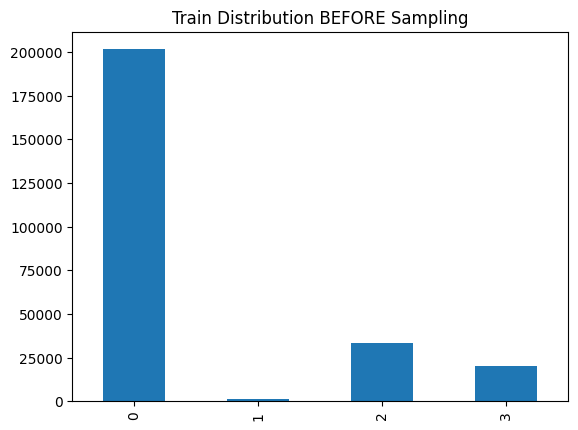

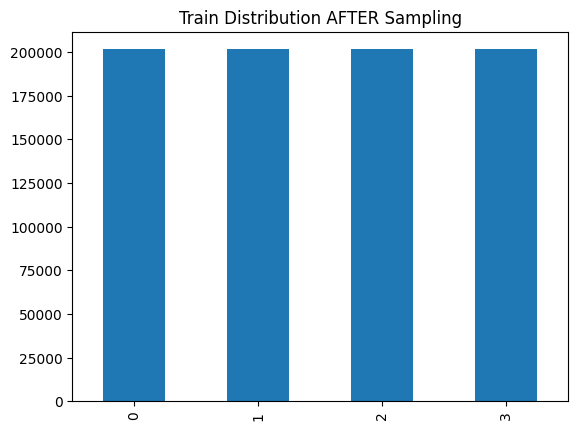

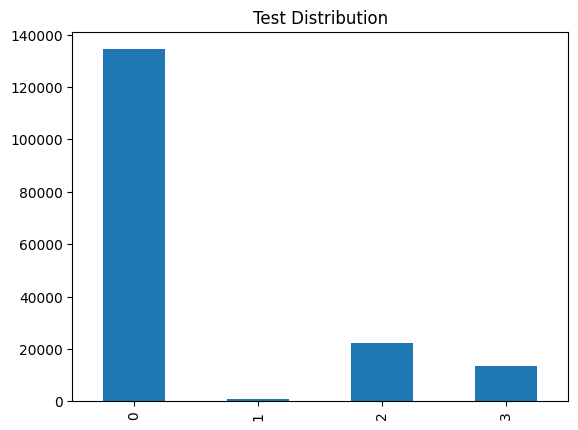

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0609, TrainAcc=0.9799, TestAcc=0.9775, ROC-AUC=0.9989
Epoch 2: Loss=0.0333, TrainAcc=0.9907, TestAcc=0.9793, ROC-AUC=0.9991
Epoch 3: Loss=0.0282, TrainAcc=0.9917, TestAcc=0.9794, ROC-AUC=0.9992
Epoch 4: Loss=0.0244, TrainAcc=0.9923, TestAcc=0.9813, ROC-AUC=0.9992
Epoch 5: Loss=0.0321, TrainAcc=0.9927, TestAcc=0.9803, ROC-AUC=0.9993
Epoch 6: Loss=0.0256, TrainAcc=0.9930, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 7: Loss=0.0218, TrainAcc=0.9932, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 8: Loss=0.0214, TrainAcc=0.9933, TestAcc=0.9805, ROC-AUC=0.9993
Epoch 9: Loss=0.0482, TrainAcc=0.9935, TestAcc=0.9810, ROC-AUC=0.9994
Epoch 10: Loss=0.0206, TrainAcc=0.9935, TestAcc=0.9808, ROC-AUC=0.9993
Epoch 11: Loss=0.0861, TrainAcc=0.9936, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 12: Loss=0.0200, TrainAcc=0.9938, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 13: Loss=0.0261, TrainAcc=0.9938, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 14: Loss=0.0193, TrainAcc=0.9940, TestAcc=

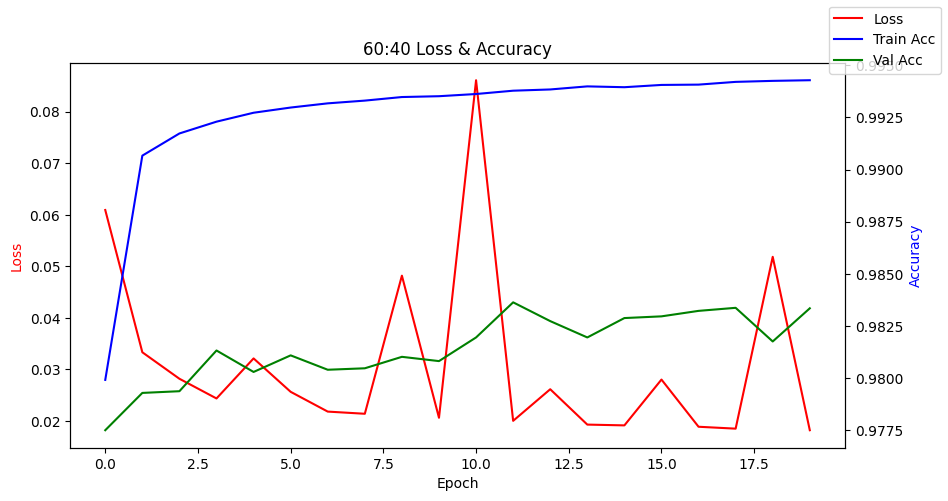

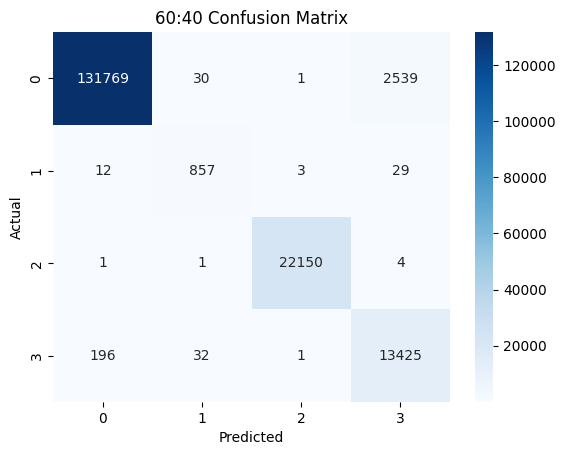

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.95      0.94       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.98      0.91     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.98      0.96    171050
weighted avg       0.99      0.98      0.98    171050



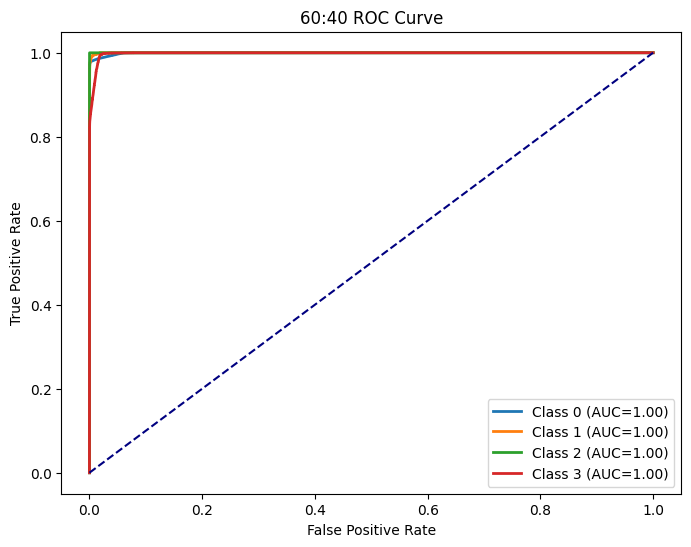

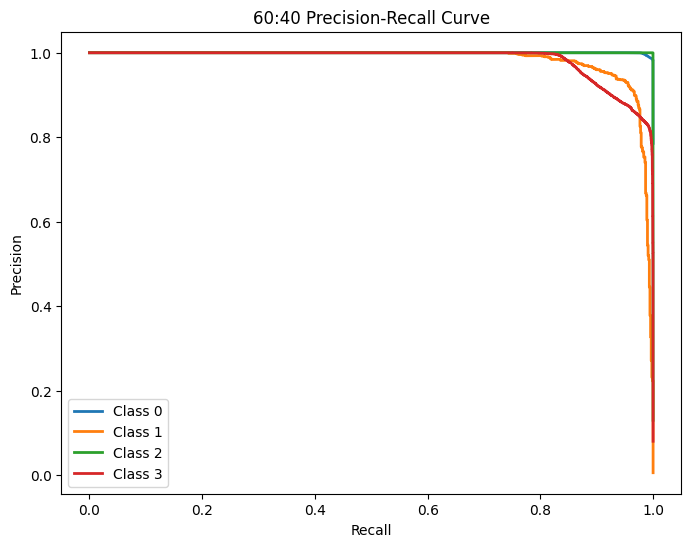


⏱️ Runtime: 760.79 sec
💾 RAM used: 481.41 MB

========== 70:30 ==========


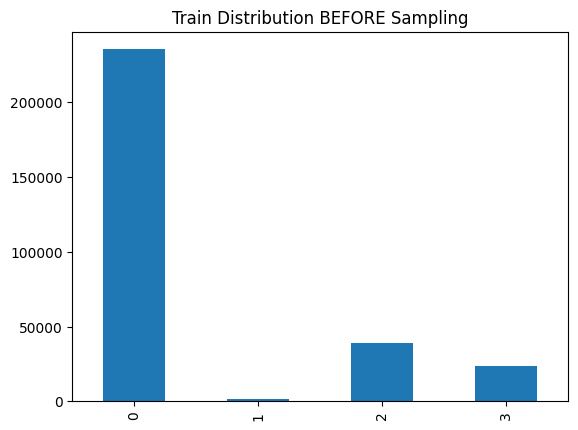

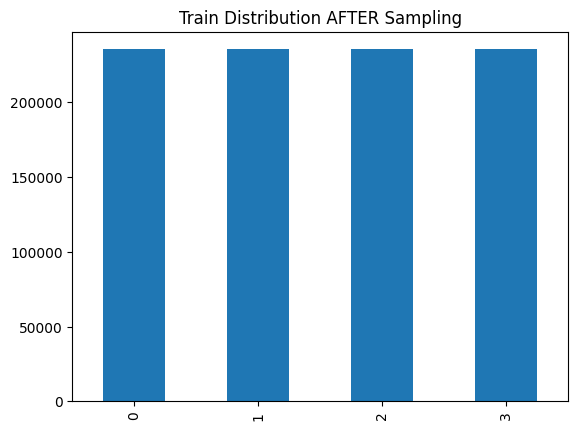

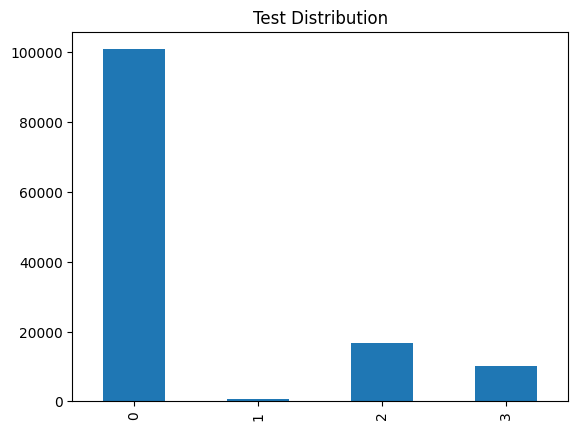

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0634, TrainAcc=0.9803, TestAcc=0.9751, ROC-AUC=0.9988
Epoch 2: Loss=0.0302, TrainAcc=0.9907, TestAcc=0.9801, ROC-AUC=0.9991
Epoch 3: Loss=0.0258, TrainAcc=0.9919, TestAcc=0.9801, ROC-AUC=0.9993
Epoch 4: Loss=0.0243, TrainAcc=0.9926, TestAcc=0.9814, ROC-AUC=0.9992
Epoch 5: Loss=0.0643, TrainAcc=0.9930, TestAcc=0.9813, ROC-AUC=0.9993
Epoch 6: Loss=0.0222, TrainAcc=0.9932, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 7: Loss=0.0259, TrainAcc=0.9934, TestAcc=0.9810, ROC-AUC=0.9993
Epoch 8: Loss=0.0910, TrainAcc=0.9934, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 9: Loss=0.9625, TrainAcc=0.9936, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 10: Loss=0.0203, TrainAcc=0.9937, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 11: Loss=0.0314, TrainAcc=0.9938, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 12: Loss=0.0192, TrainAcc=0.9941, TestAcc=0.9826, ROC-AUC=0.9994
Epoch 13: Loss=0.0200, TrainAcc=0.9940, TestAcc=0.9832, ROC-AUC=0.9994
Epoch 14: Loss=0.0190, TrainAcc=0.9940, TestAcc=

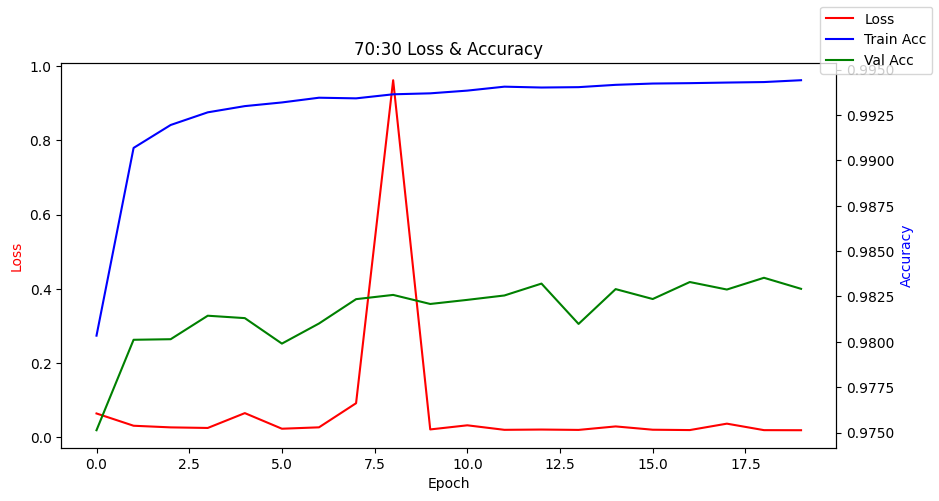

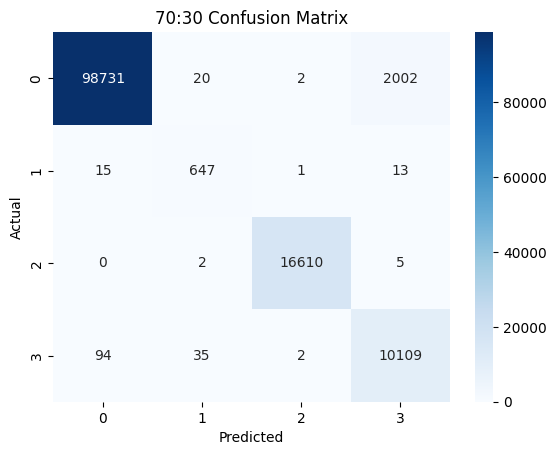

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.92      0.96      0.94       676
           2       1.00      1.00      1.00     16617
           3       0.83      0.99      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.94      0.98      0.96    128288
weighted avg       0.99      0.98      0.98    128288



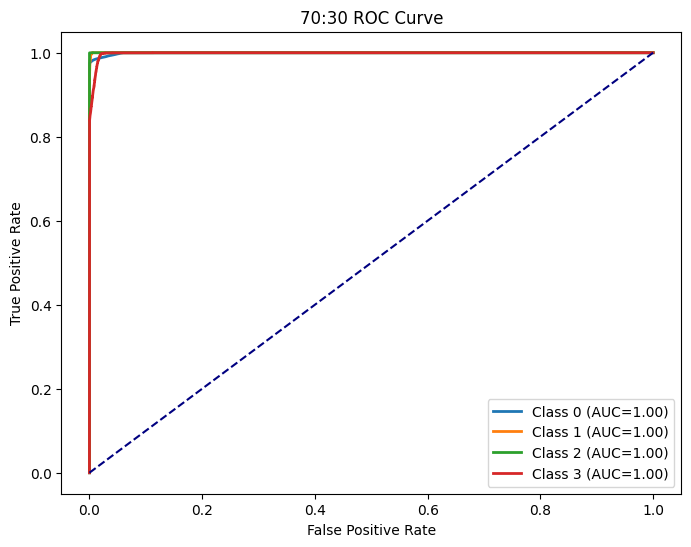

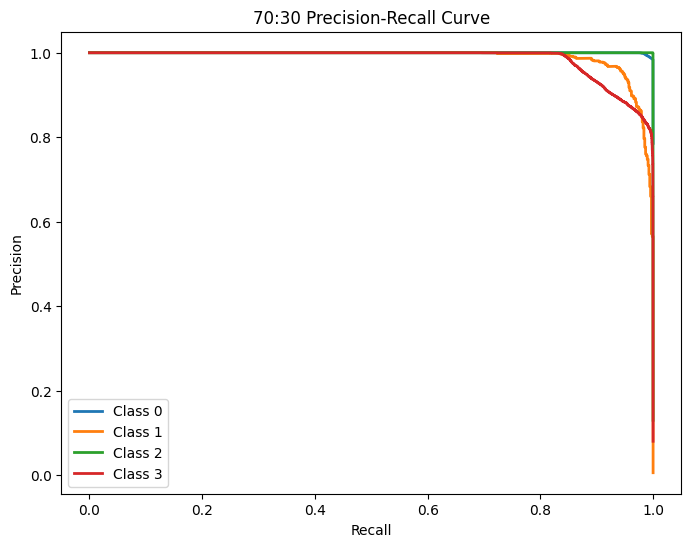


⏱️ Runtime: 874.21 sec
💾 RAM used: 424.16 MB

========== 80:20 ==========


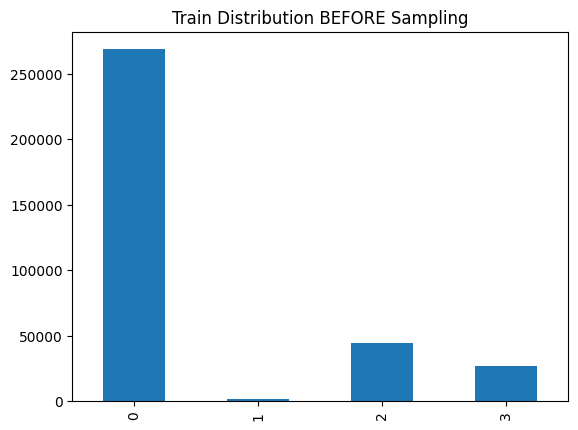

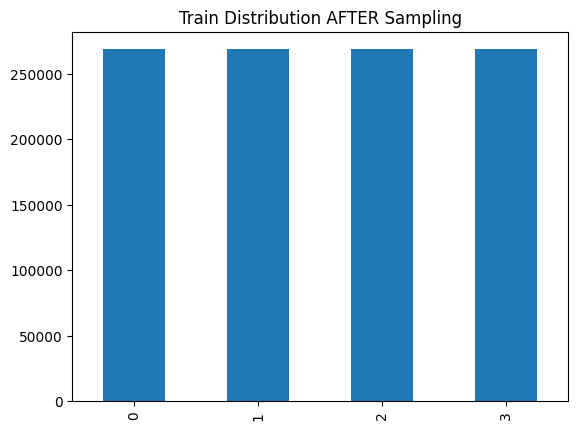

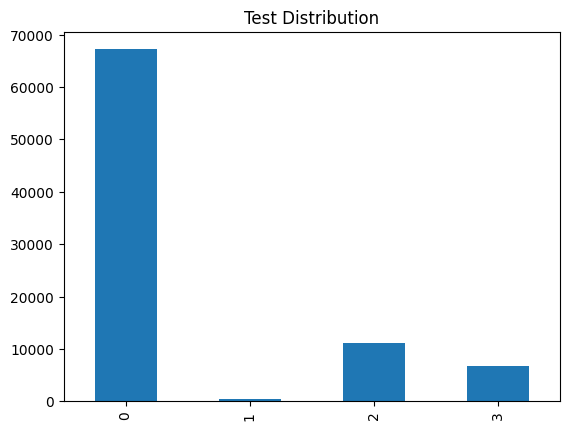

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0534, TrainAcc=0.9823, TestAcc=0.9742, ROC-AUC=0.9990
Epoch 2: Loss=0.0296, TrainAcc=0.9907, TestAcc=0.9775, ROC-AUC=0.9992
Epoch 3: Loss=0.0280, TrainAcc=0.9918, TestAcc=0.9786, ROC-AUC=0.9992
Epoch 4: Loss=0.0280, TrainAcc=0.9925, TestAcc=0.9798, ROC-AUC=0.9993
Epoch 5: Loss=0.0235, TrainAcc=0.9928, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 6: Loss=0.0519, TrainAcc=0.9932, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 7: Loss=0.0228, TrainAcc=0.9933, TestAcc=0.9815, ROC-AUC=0.9994
Epoch 8: Loss=0.0214, TrainAcc=0.9933, TestAcc=0.9790, ROC-AUC=0.9993
Epoch 9: Loss=0.0264, TrainAcc=0.9933, TestAcc=0.9824, ROC-AUC=0.9993
Epoch 10: Loss=0.0446, TrainAcc=0.9936, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 11: Loss=0.0438, TrainAcc=0.9938, TestAcc=0.9829, ROC-AUC=0.9994
Epoch 12: Loss=0.0200, TrainAcc=0.9938, TestAcc=0.9835, ROC-AUC=0.9994
Epoch 13: Loss=0.0209, TrainAcc=0.9939, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 14: Loss=0.0207, TrainAcc=0.9939, TestAcc=

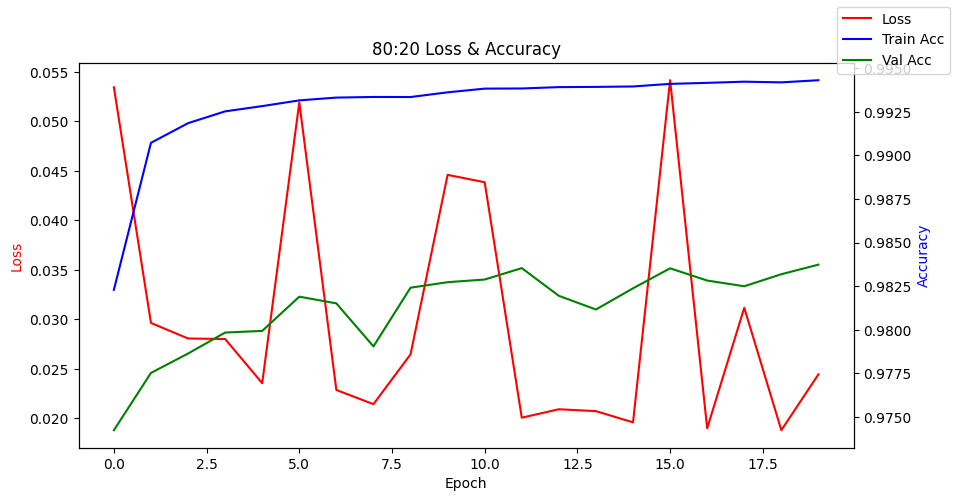

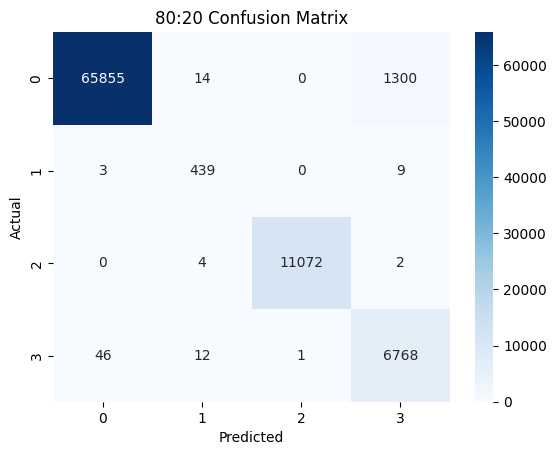

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.94      0.97      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.84      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



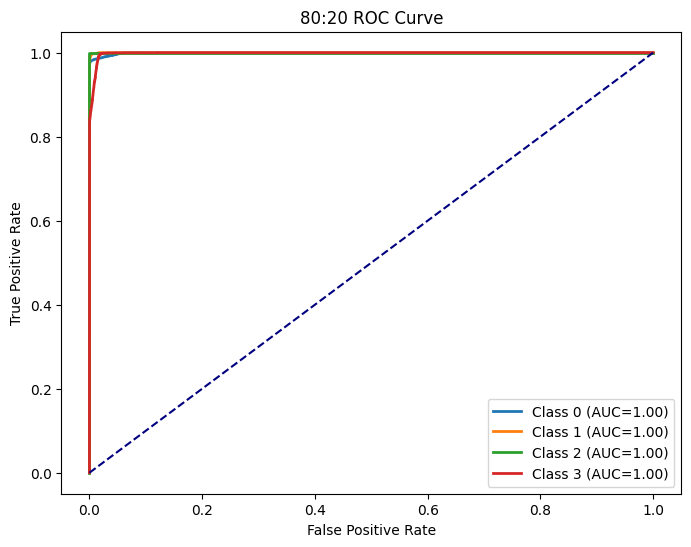

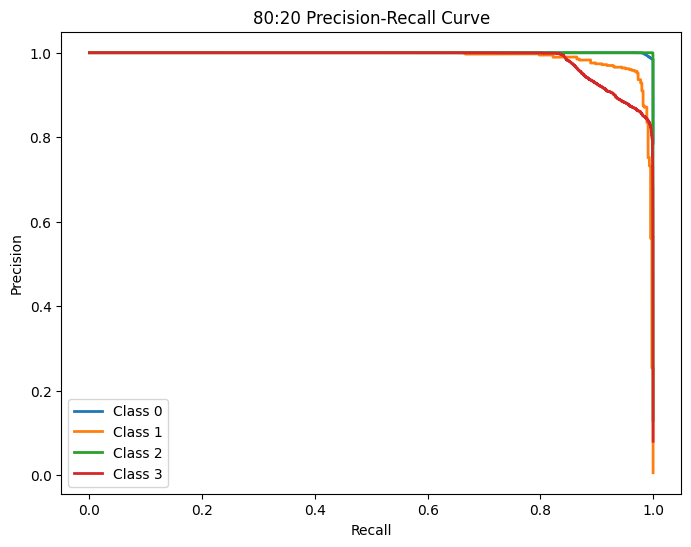


⏱️ Runtime: 993.31 sec
💾 RAM used: 475.98 MB


In [10]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# SMOTE

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} - SMOTE ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # Train distribution before sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE Sampling")
    plt.show()

    # SMOTE oversampling
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Train distribution after sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER Sampling")
    plt.show()

    # RobustScaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # Model & training
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train), dtype=torch.float32).to(device)
    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)
        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # Plots
    # Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy - SMOTE")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix - SMOTE")
    plt.show()
    print(classification_report(true, preds))

    # ROC Curve
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Runtime & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram
    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {ram_used:.2f} MB")


========== 60:40 - SMOTE ==========


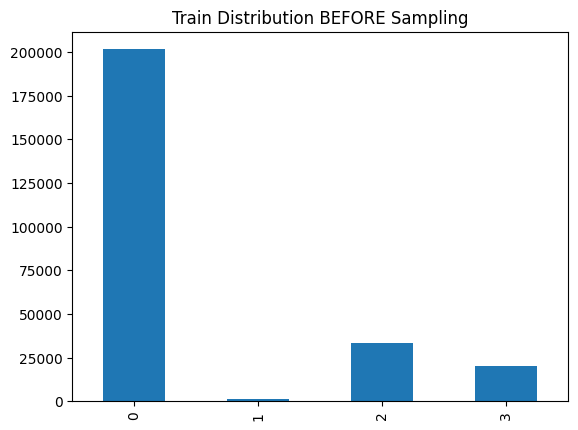

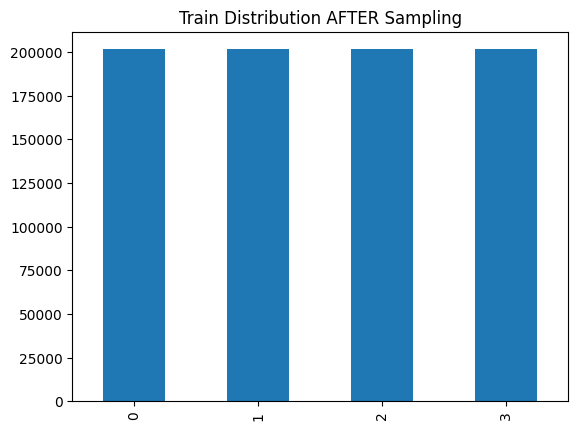

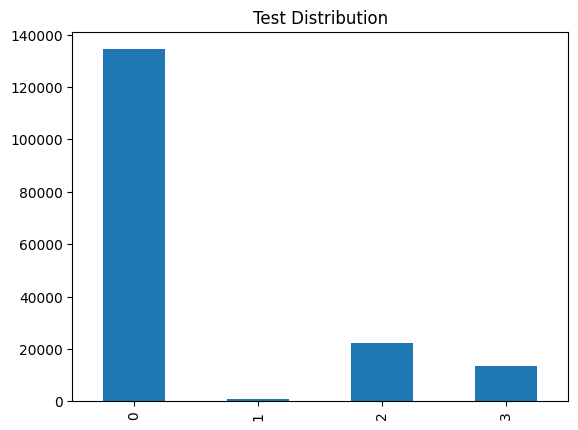

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.0610, TrainAcc=0.9786, TestAcc=0.9713, ROC-AUC=0.9989
Epoch 2: Loss=0.0299, TrainAcc=0.9899, TestAcc=0.9772, ROC-AUC=0.9991
Epoch 3: Loss=0.0259, TrainAcc=0.9913, TestAcc=0.9812, ROC-AUC=0.9991
Epoch 4: Loss=0.0245, TrainAcc=0.9920, TestAcc=0.9783, ROC-AUC=0.9992
Epoch 5: Loss=0.0224, TrainAcc=0.9925, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 6: Loss=0.0215, TrainAcc=0.9927, TestAcc=0.9807, ROC-AUC=0.9993
Epoch 7: Loss=0.0210, TrainAcc=0.9930, TestAcc=0.9809, ROC-AUC=0.9993
Epoch 8: Loss=0.0204, TrainAcc=0.9931, TestAcc=0.9800, ROC-AUC=0.9993
Epoch 9: Loss=0.0203, TrainAcc=0.9931, TestAcc=0.9802, ROC-AUC=0.9992
Epoch 10: Loss=0.0295, TrainAcc=0.9933, TestAcc=0.9812, ROC-AUC=0.9993
Epoch 11: Loss=0.0198, TrainAcc=0.9934, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 12: Loss=0.0191, TrainAcc=0.9935, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 13: Loss=0.0195, TrainAcc=0.9936, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 14: Loss=0.0189, TrainAcc=0.9936, TestAcc=

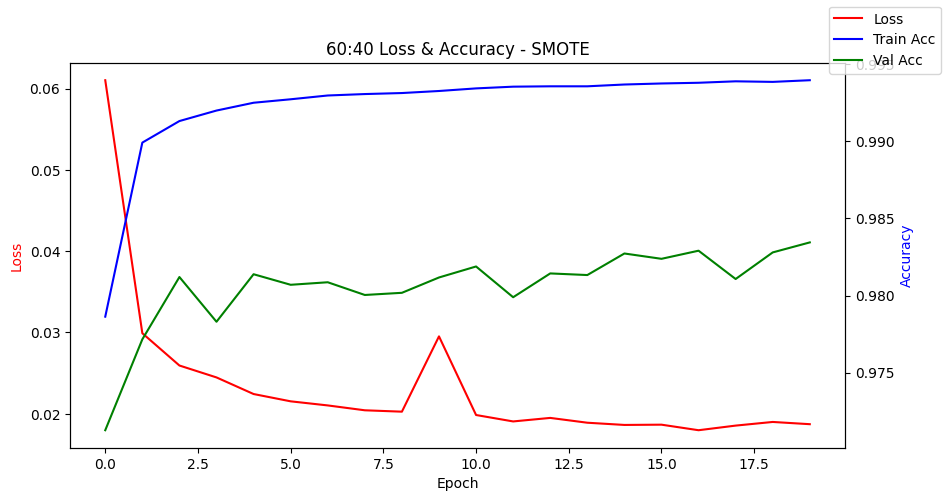

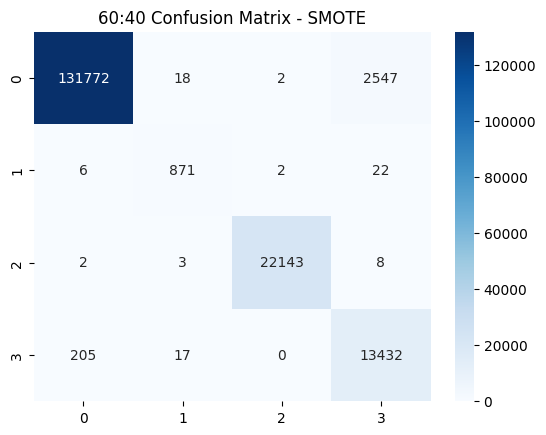

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.96      0.97      0.96       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.98      0.91     13654

    accuracy                           0.98    171050
   macro avg       0.95      0.98      0.96    171050
weighted avg       0.99      0.98      0.98    171050



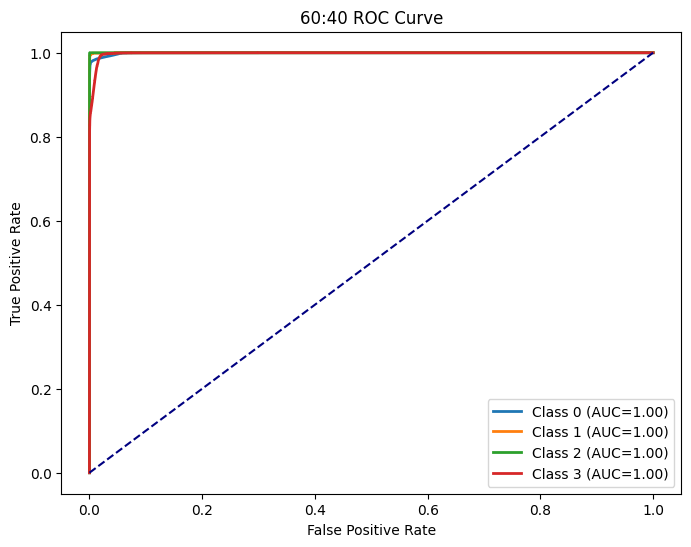

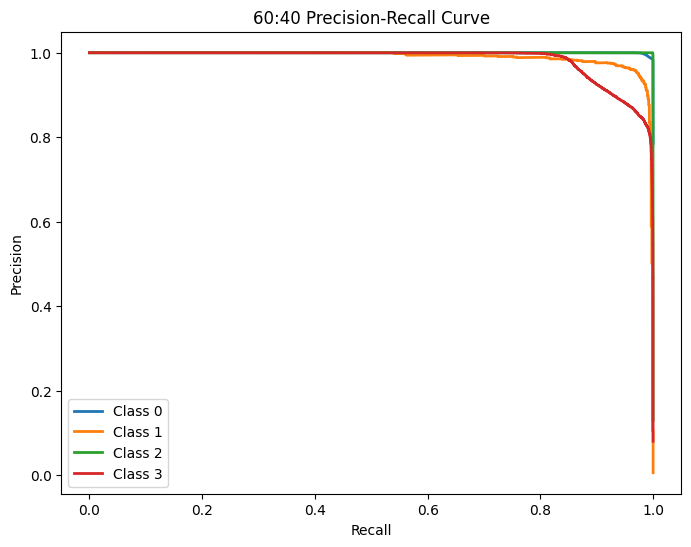


⏱️ Runtime: 713.13 sec
💾 RAM used: 299.80 MB

========== 70:30 - SMOTE ==========


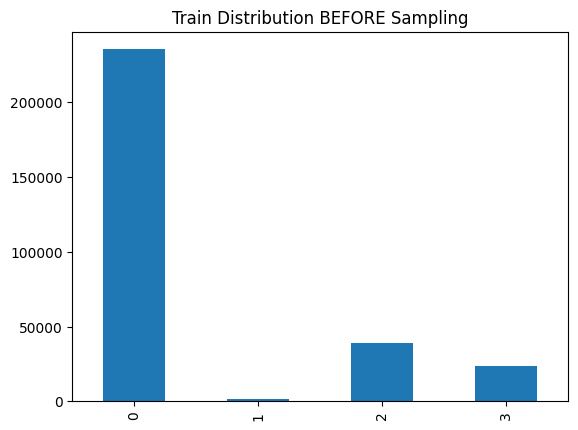

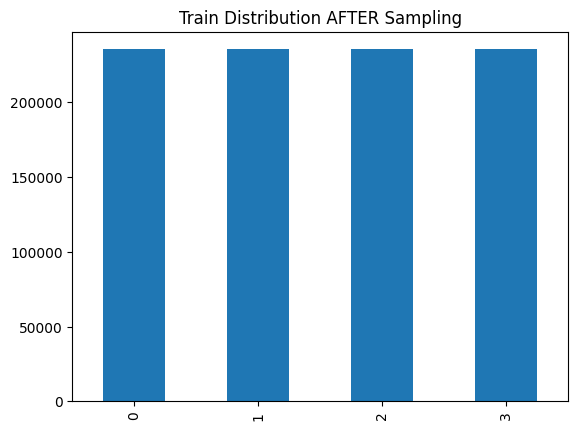

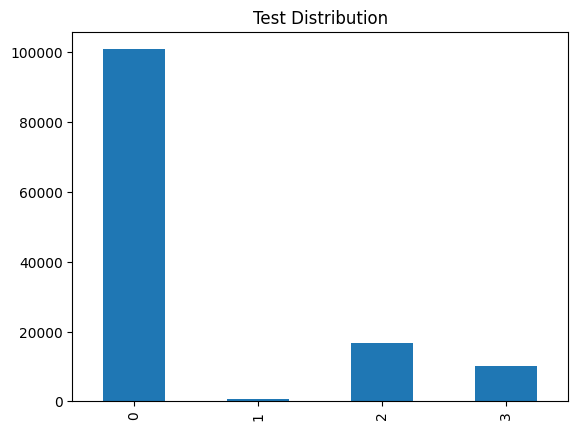

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.0623, TrainAcc=0.9811, TestAcc=0.9702, ROC-AUC=0.9989
Epoch 2: Loss=0.0265, TrainAcc=0.9910, TestAcc=0.9786, ROC-AUC=0.9991
Epoch 3: Loss=0.0385, TrainAcc=0.9918, TestAcc=0.9783, ROC-AUC=0.9992
Epoch 4: Loss=0.0227, TrainAcc=0.9925, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 5: Loss=0.0219, TrainAcc=0.9928, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 6: Loss=0.0212, TrainAcc=0.9931, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 7: Loss=0.0201, TrainAcc=0.9934, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 8: Loss=0.0188, TrainAcc=0.9935, TestAcc=0.9830, ROC-AUC=0.9993
Epoch 9: Loss=0.0186, TrainAcc=0.9936, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 10: Loss=0.0184, TrainAcc=0.9937, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 11: Loss=0.0186, TrainAcc=0.9938, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 12: Loss=0.0183, TrainAcc=0.9938, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 13: Loss=0.0174, TrainAcc=0.9940, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 14: Loss=0.0220, TrainAcc=0.9940, TestAcc=

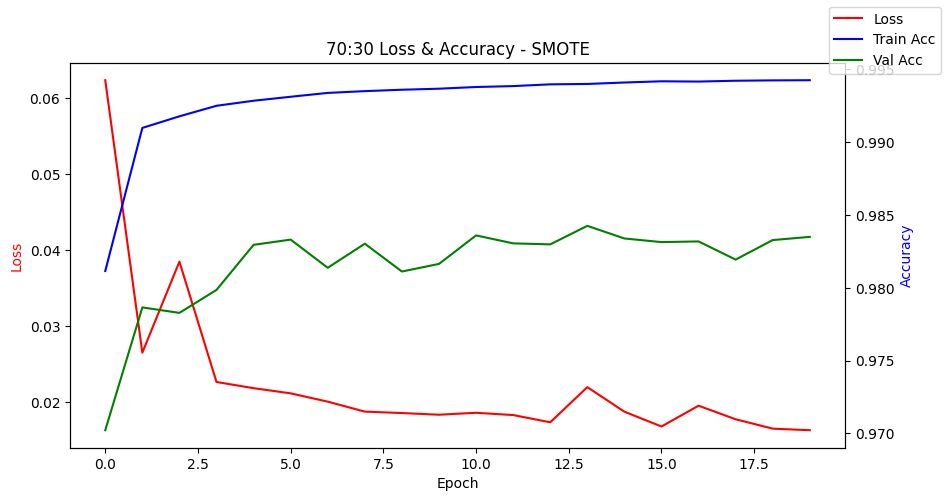

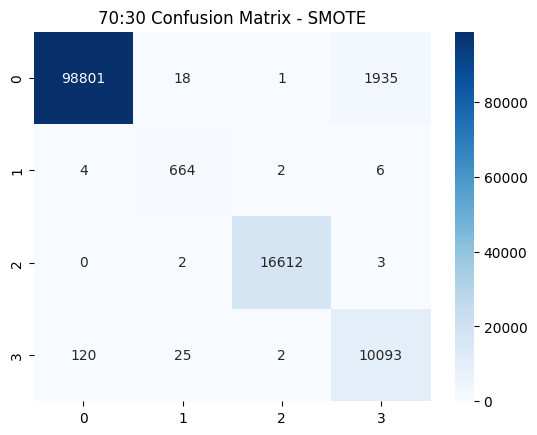

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.94      0.98      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.84      0.99      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.94      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



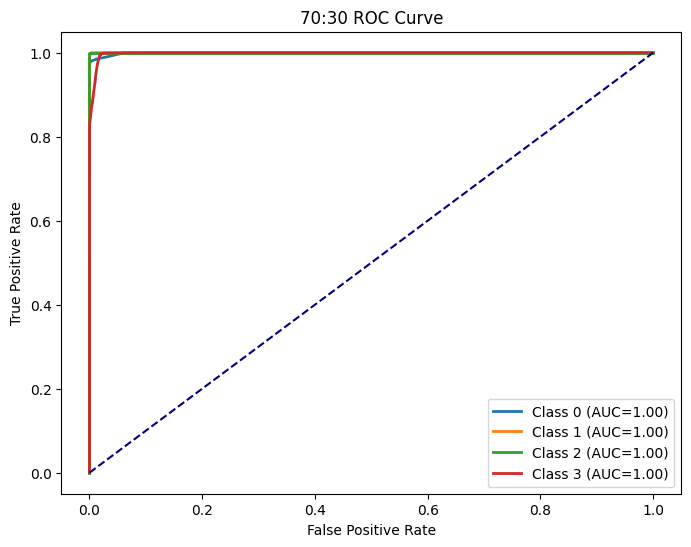

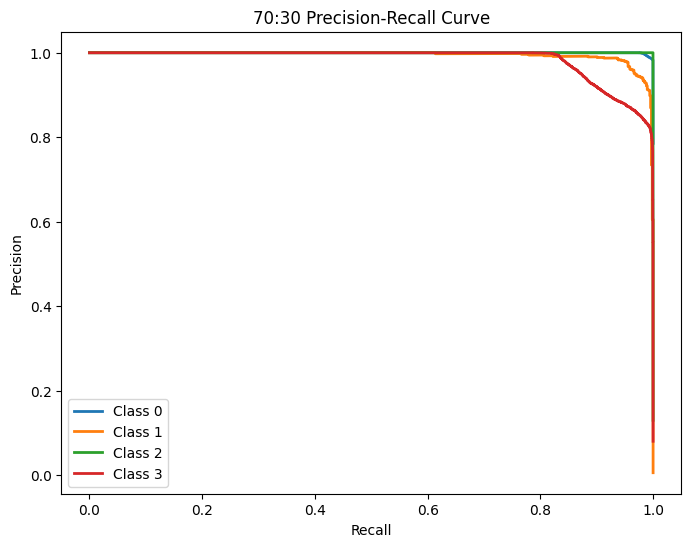


⏱️ Runtime: 816.36 sec
💾 RAM used: 284.41 MB

========== 80:20 - SMOTE ==========


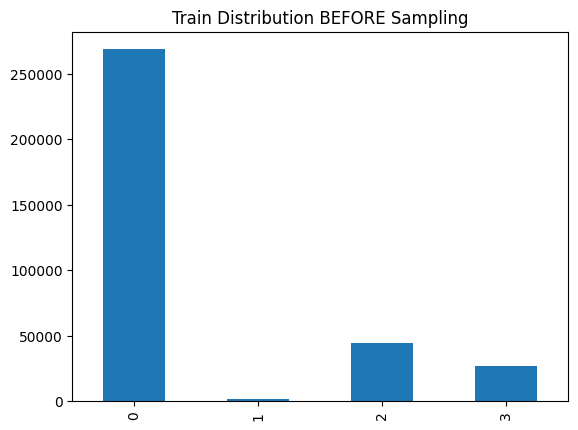

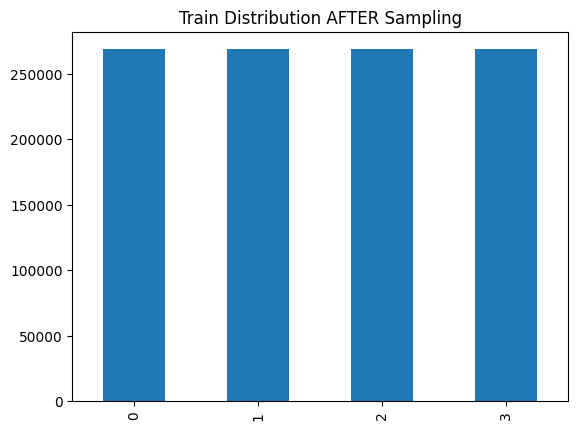

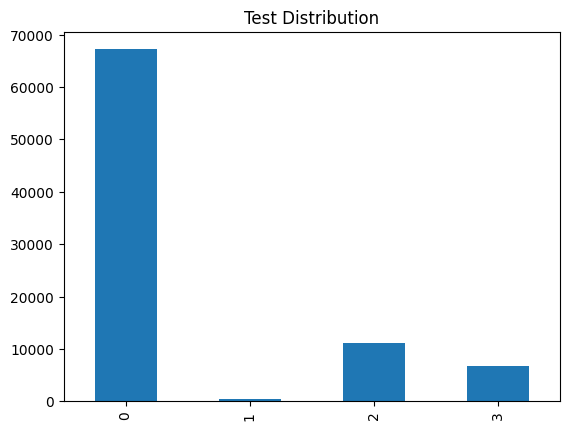

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.0644, TrainAcc=0.9803, TestAcc=0.9720, ROC-AUC=0.9990
Epoch 2: Loss=0.0280, TrainAcc=0.9908, TestAcc=0.9765, ROC-AUC=0.9991
Epoch 3: Loss=0.0250, TrainAcc=0.9917, TestAcc=0.9795, ROC-AUC=0.9992
Epoch 4: Loss=0.0237, TrainAcc=0.9922, TestAcc=0.9799, ROC-AUC=0.9992
Epoch 5: Loss=0.0228, TrainAcc=0.9925, TestAcc=0.9794, ROC-AUC=0.9992
Epoch 6: Loss=0.0217, TrainAcc=0.9928, TestAcc=0.9779, ROC-AUC=0.9992
Epoch 7: Loss=0.0214, TrainAcc=0.9929, TestAcc=0.9807, ROC-AUC=0.9992
Epoch 8: Loss=0.0256, TrainAcc=0.9931, TestAcc=0.9805, ROC-AUC=0.9993
Epoch 9: Loss=0.0200, TrainAcc=0.9932, TestAcc=0.9805, ROC-AUC=0.9992
Epoch 10: Loss=0.0199, TrainAcc=0.9933, TestAcc=0.9821, ROC-AUC=0.9993
Epoch 11: Loss=0.0202, TrainAcc=0.9933, TestAcc=0.9833, ROC-AUC=0.9993
Epoch 12: Loss=0.0208, TrainAcc=0.9934, TestAcc=0.9805, ROC-AUC=0.9993
Epoch 13: Loss=0.0348, TrainAcc=0.9935, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 14: Loss=0.0220, TrainAcc=0.9936, TestAcc=

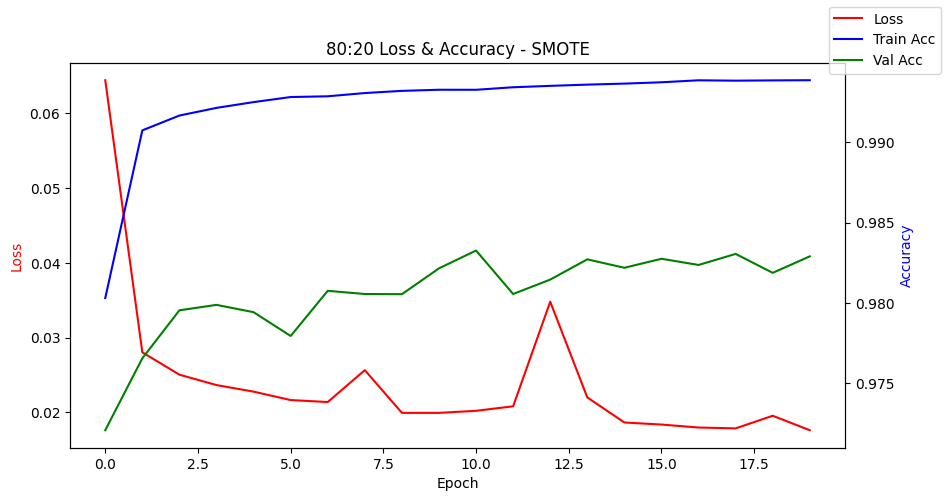

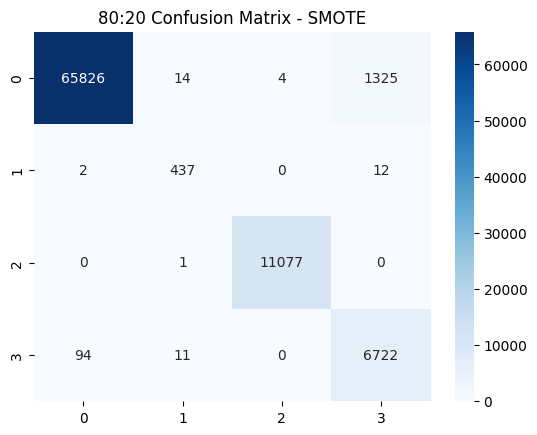

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.94      0.97      0.96       451
           2       1.00      1.00      1.00     11078
           3       0.83      0.98      0.90      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.98      0.96     85525
weighted avg       0.99      0.98      0.98     85525



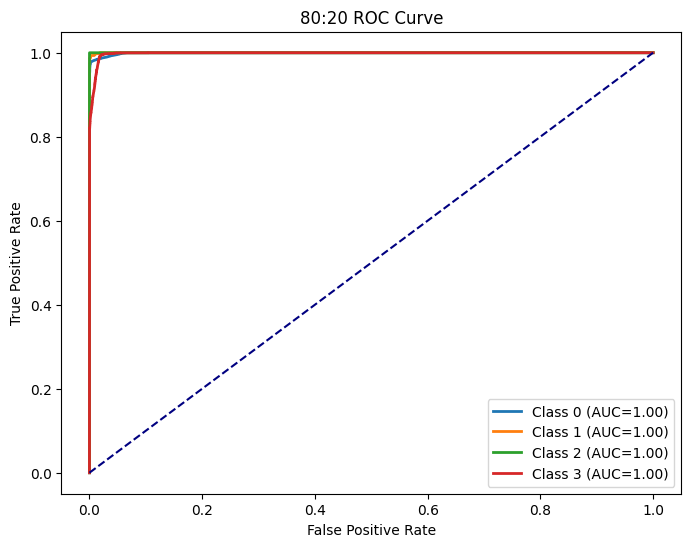

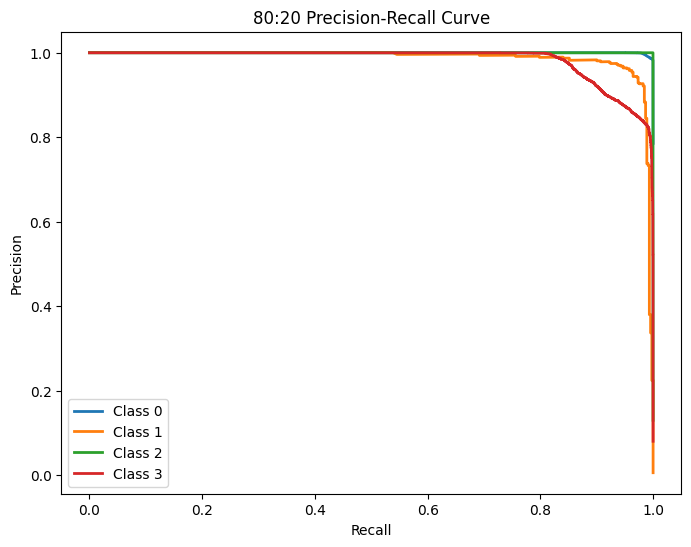


⏱️ Runtime: 917.48 sec
💾 RAM used: -34.02 MB


In [24]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", test_size=0.4)
run_split_smote(df, "70:30", test_size=0.3)
run_split_smote(df, "80:20", test_size=0.2)

# ADASYN

In [9]:
from imblearn.over_sampling import ADASYN

def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} - ADASYN ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train distribution before sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE Sampling")
    plt.show()

    # ADASYN oversampling
    adasyn = ADASYN(random_state=42)
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # Train distribution after sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER Sampling")
    plt.show()

    # RobustScaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train), "Test size:", len(y_test))

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train), dtype=torch.float32).to(device)
    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)
        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

   # Plots
    # Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy - SMOTE")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix - SMOTE")
    plt.show()
    print(classification_report(true, preds))

    # ROC Curve
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Runtime & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram
    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {ram_used:.2f} MB")


========== 60:40 - ADASYN ==========


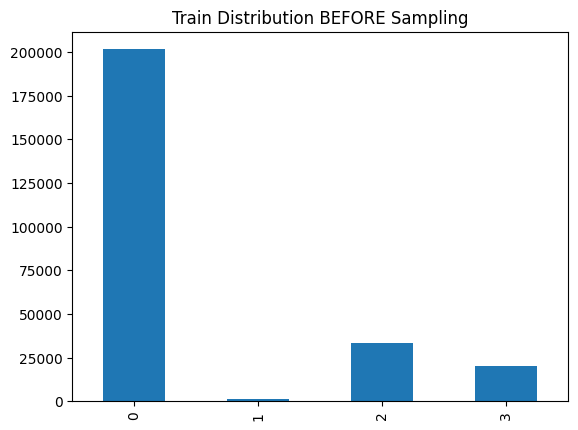

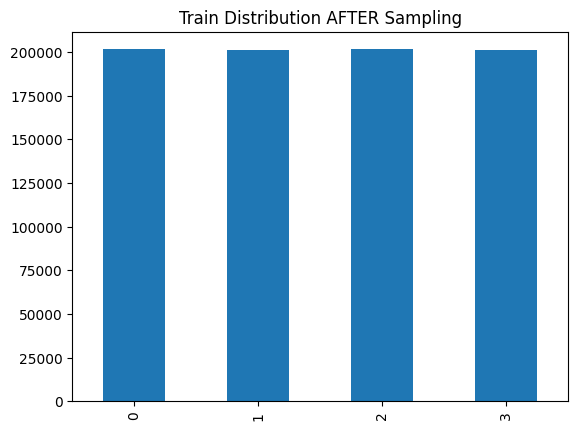

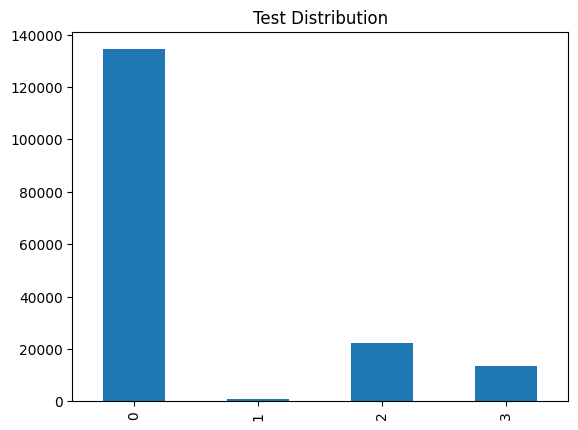

Train size: 805442 Test size: 171050
Epoch 1: Loss=0.0694, TrainAcc=0.9777, TestAcc=0.9685, ROC-AUC=0.9989
Epoch 2: Loss=0.0348, TrainAcc=0.9891, TestAcc=0.9777, ROC-AUC=0.9992
Epoch 3: Loss=0.0292, TrainAcc=0.9908, TestAcc=0.9780, ROC-AUC=0.9992
Epoch 4: Loss=0.0275, TrainAcc=0.9914, TestAcc=0.9807, ROC-AUC=0.9992
Epoch 5: Loss=0.0257, TrainAcc=0.9919, TestAcc=0.9813, ROC-AUC=0.9993
Epoch 6: Loss=0.0243, TrainAcc=0.9923, TestAcc=0.9811, ROC-AUC=0.9993
Epoch 7: Loss=0.0236, TrainAcc=0.9925, TestAcc=0.9816, ROC-AUC=0.9993
Epoch 8: Loss=0.0228, TrainAcc=0.9928, TestAcc=0.9821, ROC-AUC=0.9993
Epoch 9: Loss=0.0222, TrainAcc=0.9930, TestAcc=0.9835, ROC-AUC=0.9994
Epoch 10: Loss=0.0220, TrainAcc=0.9930, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 11: Loss=0.0214, TrainAcc=0.9933, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 12: Loss=0.0210, TrainAcc=0.9934, TestAcc=0.9834, ROC-AUC=0.9993
Epoch 13: Loss=0.0209, TrainAcc=0.9934, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 14: Loss=0.0205, TrainAcc=0.9936, TestAcc=0

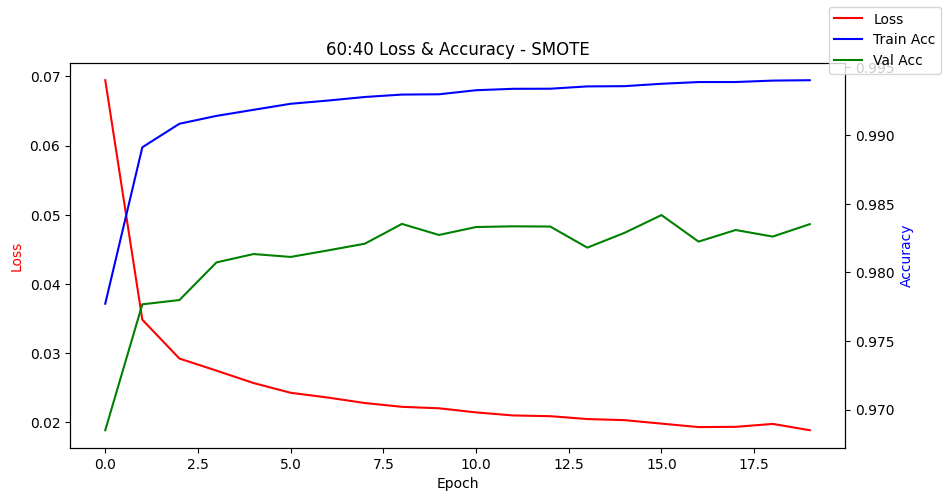

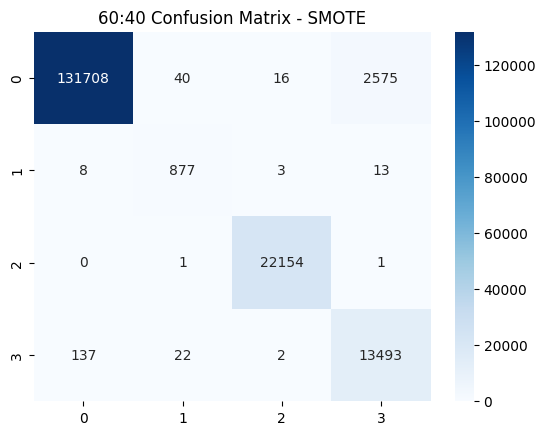

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.93      0.97      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.84      0.99      0.91     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.98      0.98    171050



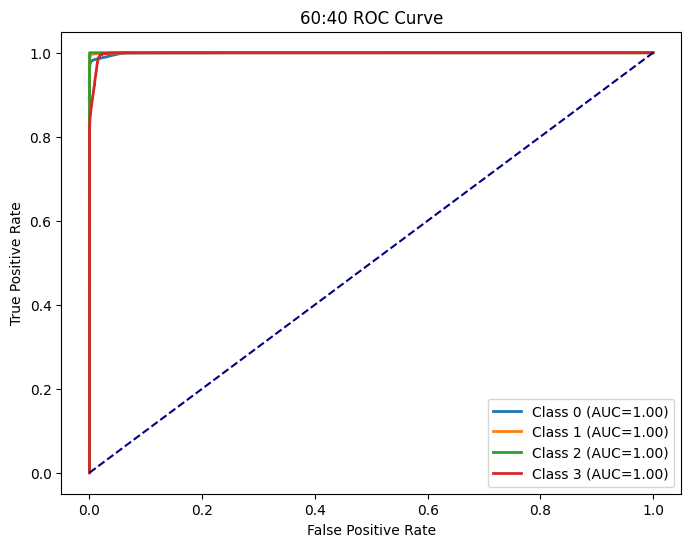

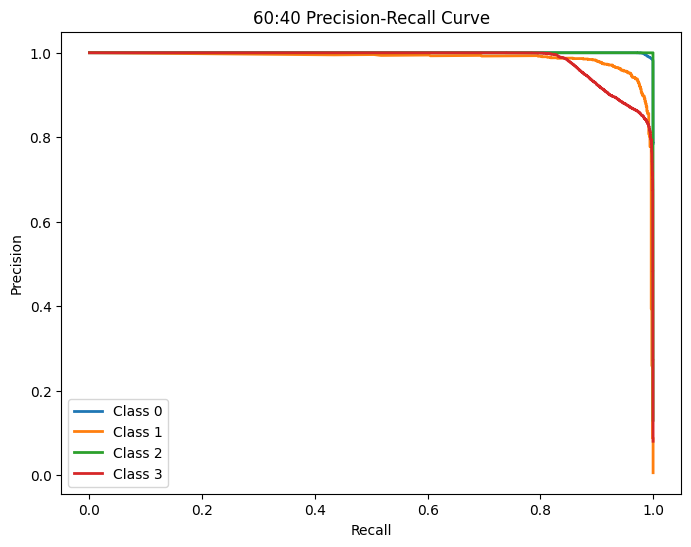


⏱️ Runtime: 1151.83 sec
💾 RAM used: 1019.22 MB

========== 70:30 - ADASYN ==========


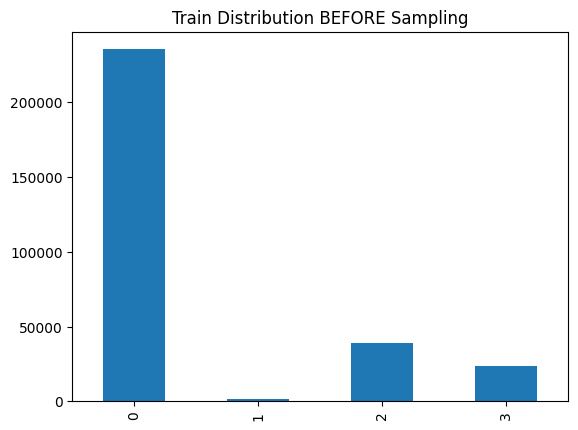

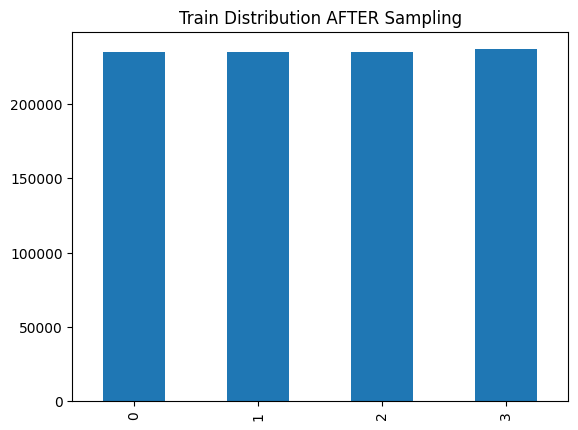

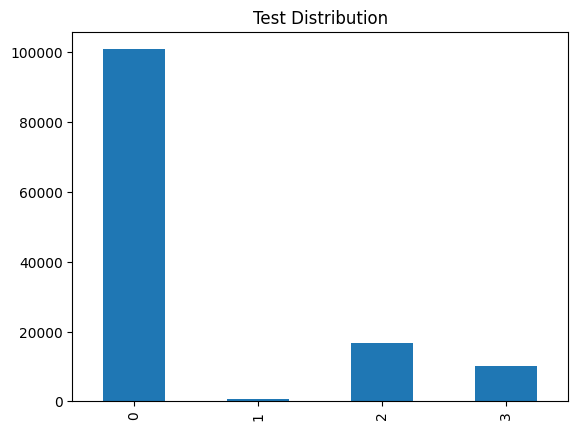

Train size: 942085 Test size: 128288
Epoch 1: Loss=0.0674, TrainAcc=0.9777, TestAcc=0.9733, ROC-AUC=0.9991
Epoch 2: Loss=0.0339, TrainAcc=0.9896, TestAcc=0.9768, ROC-AUC=0.9992
Epoch 3: Loss=0.0299, TrainAcc=0.9908, TestAcc=0.9785, ROC-AUC=0.9992
Epoch 4: Loss=0.0272, TrainAcc=0.9917, TestAcc=0.9792, ROC-AUC=0.9992
Epoch 5: Loss=0.0260, TrainAcc=0.9920, TestAcc=0.9803, ROC-AUC=0.9993
Epoch 6: Loss=0.0250, TrainAcc=0.9922, TestAcc=0.9783, ROC-AUC=0.9994
Epoch 7: Loss=0.0238, TrainAcc=0.9927, TestAcc=0.9823, ROC-AUC=0.9993
Epoch 8: Loss=0.0233, TrainAcc=0.9928, TestAcc=0.9802, ROC-AUC=0.9994
Epoch 9: Loss=0.0232, TrainAcc=0.9930, TestAcc=0.9811, ROC-AUC=0.9994
Epoch 10: Loss=0.0221, TrainAcc=0.9932, TestAcc=0.9829, ROC-AUC=0.9994
Epoch 11: Loss=0.0237, TrainAcc=0.9932, TestAcc=0.9838, ROC-AUC=0.9993
Epoch 12: Loss=0.0234, TrainAcc=0.9933, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 13: Loss=0.0233, TrainAcc=0.9933, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 14: Loss=0.0215, TrainAcc=0.9935, TestAcc=0

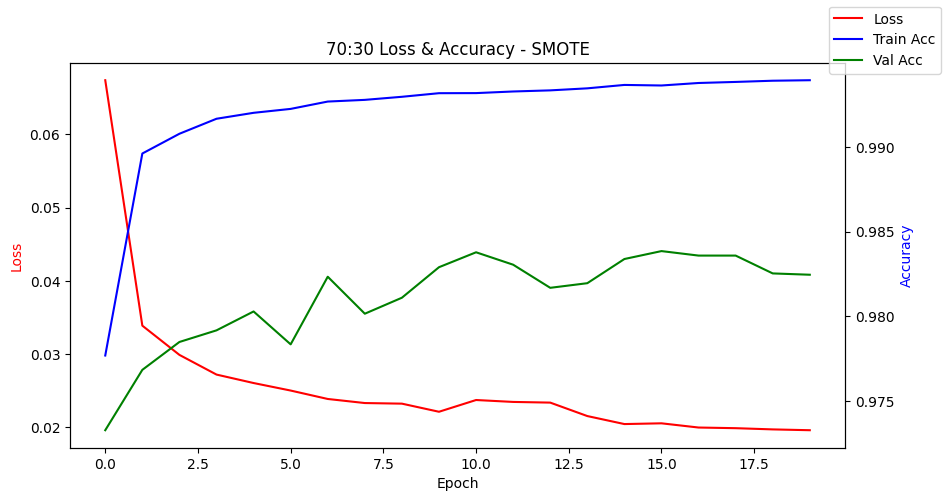

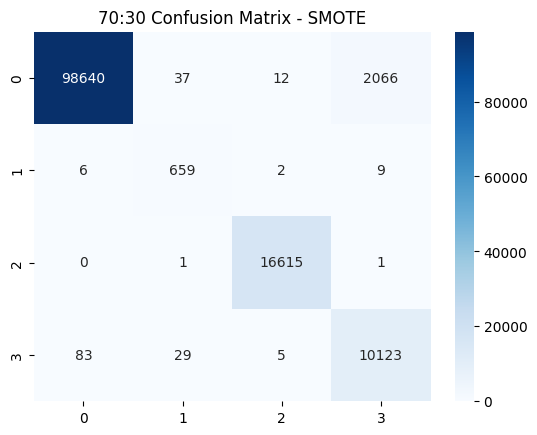

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.91      0.97      0.94       676
           2       1.00      1.00      1.00     16617
           3       0.83      0.99      0.90     10240

    accuracy                           0.98    128288
   macro avg       0.93      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



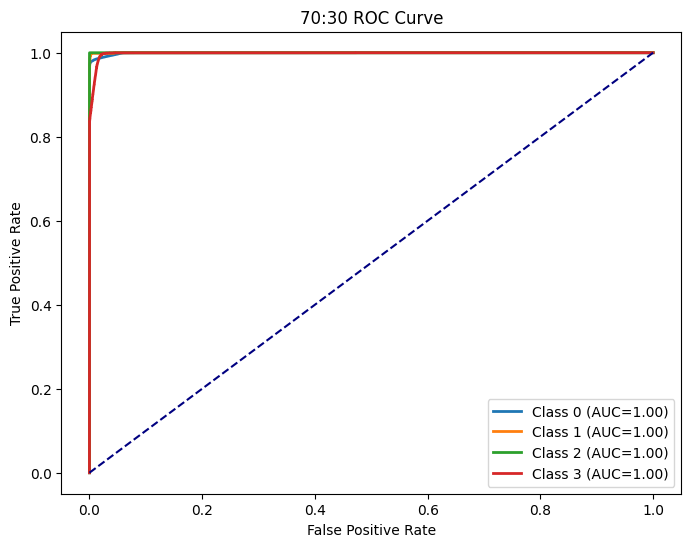

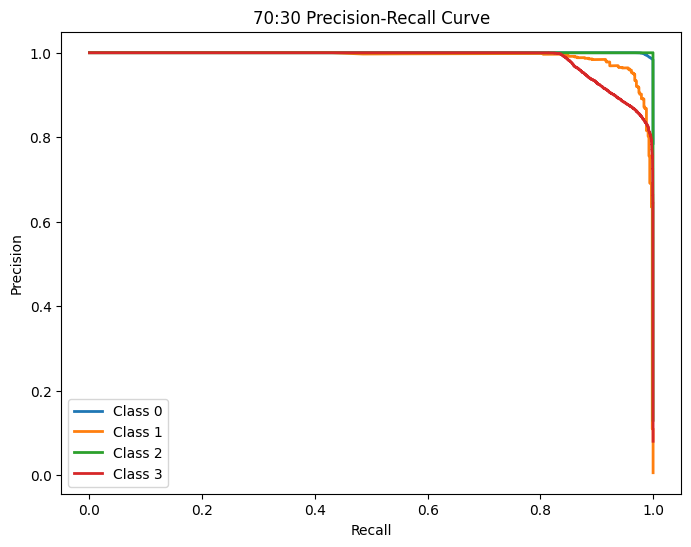


⏱️ Runtime: 1291.96 sec
💾 RAM used: 364.85 MB

========== 80:20 - ADASYN ==========


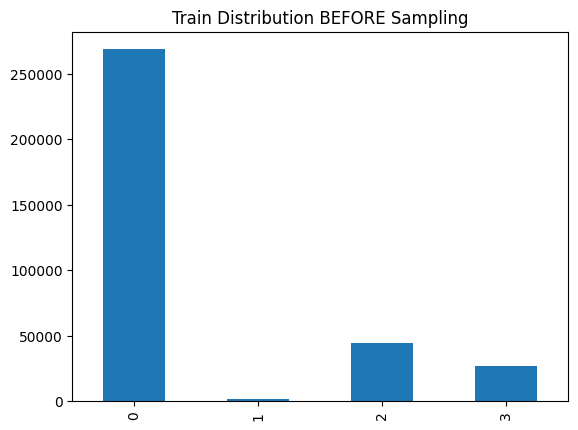

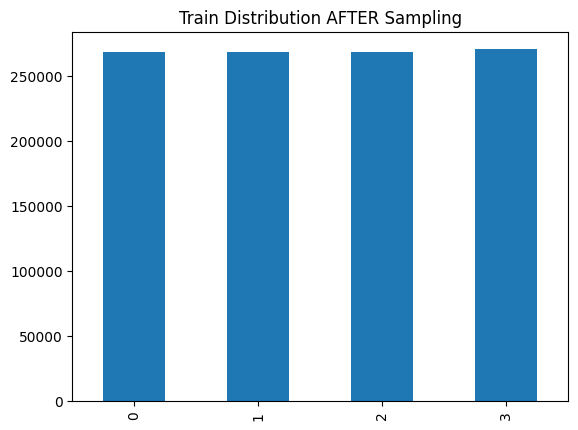

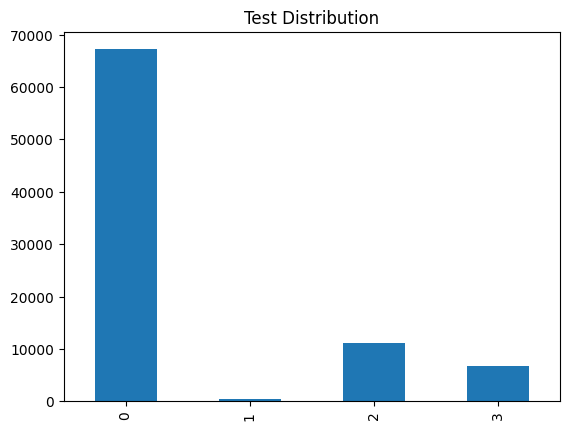

Train size: 1076489 Test size: 85525
Epoch 1: Loss=0.0651, TrainAcc=0.9784, TestAcc=0.9709, ROC-AUC=0.9990
Epoch 2: Loss=0.0347, TrainAcc=0.9894, TestAcc=0.9761, ROC-AUC=0.9992
Epoch 3: Loss=0.0314, TrainAcc=0.9905, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 4: Loss=0.0281, TrainAcc=0.9913, TestAcc=0.9794, ROC-AUC=0.9993
Epoch 5: Loss=0.0263, TrainAcc=0.9919, TestAcc=0.9821, ROC-AUC=0.9993
Epoch 6: Loss=0.0261, TrainAcc=0.9923, TestAcc=0.9810, ROC-AUC=0.9993
Epoch 7: Loss=0.0243, TrainAcc=0.9925, TestAcc=0.9811, ROC-AUC=0.9994
Epoch 8: Loss=0.0235, TrainAcc=0.9927, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 9: Loss=0.0240, TrainAcc=0.9929, TestAcc=0.9790, ROC-AUC=0.9992
Epoch 10: Loss=0.0222, TrainAcc=0.9931, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 11: Loss=0.0229, TrainAcc=0.9932, TestAcc=0.9813, ROC-AUC=0.9993
Epoch 12: Loss=0.0218, TrainAcc=0.9933, TestAcc=0.9841, ROC-AUC=0.9994
Epoch 13: Loss=0.0213, TrainAcc=0.9934, TestAcc=0.9827, ROC-AUC=0.9994
Epoch 14: Loss=0.0212, TrainAcc=0.9934, TestAcc=0

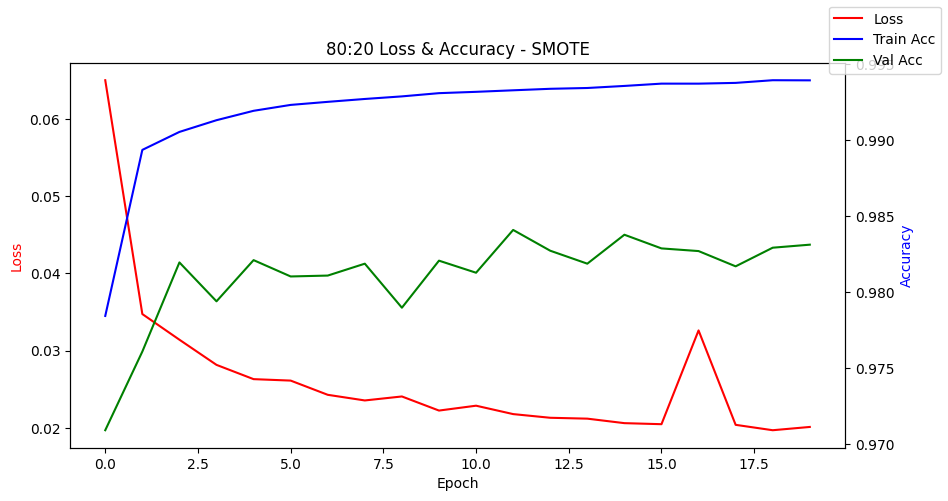

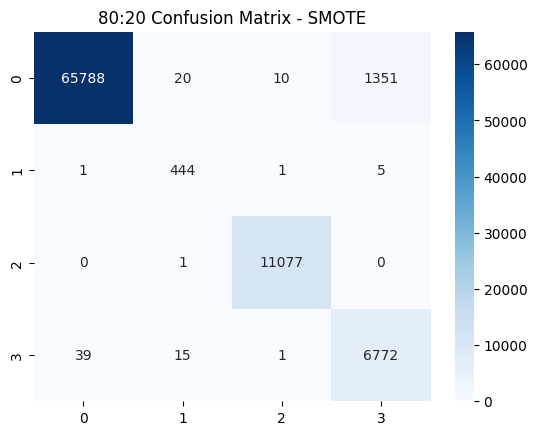

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.93      0.98      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.83      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.94      0.99      0.96     85525
weighted avg       0.99      0.98      0.98     85525



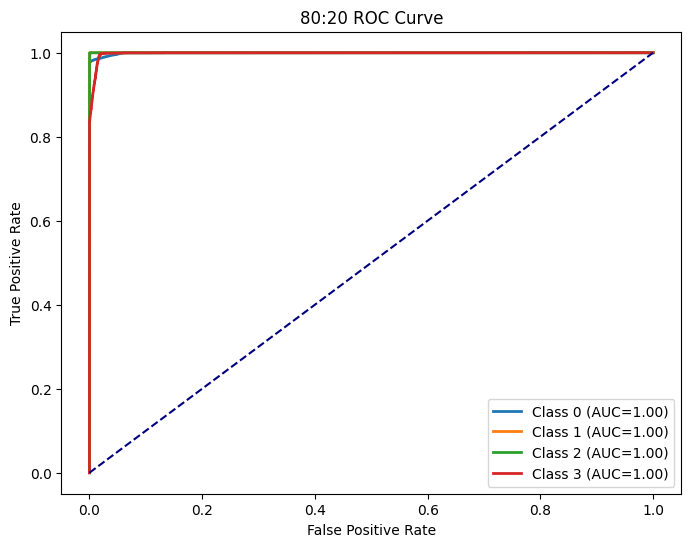

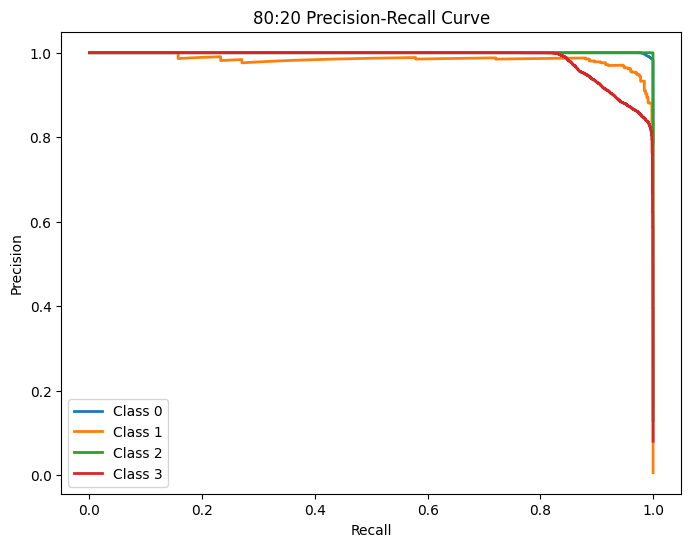


⏱️ Runtime: 1437.87 sec
💾 RAM used: 423.63 MB


In [10]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", test_size=0.4)
run_split_adasyn(df, "70:30", test_size=0.3)
run_split_adasyn(df, "80:20", test_size=0.2)

# ADASYN + Tomek_Links

In [11]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} - ADASYN + TomekLinks ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train distribution before sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE Sampling")
    plt.show()

    # ADASYN oversampling
    adasyn = ADASYN(random_state=42)
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # TomekLinks undersampling
    tomek = TomekLinks()
    X_train, y_train = tomek.fit_resample(X_train, y_train)

    # Train distribution after sampling
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER Sampling")
    plt.show()

    # RobustScaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train), "Test size:", len(y_test))

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train), dtype=torch.float32).to(device)
    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)
        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # Plots
    # Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], color="red", label="Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], color="blue", label="Train Acc")
    ax2.plot(history["val_acc"], color="green", label="Val Acc")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy - SMOTE")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix - SMOTE")
    plt.show()
    print(classification_report(true, preds))

    # ROC Curve
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc_val:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Runtime & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram
    print(f"\n⏱️ Runtime: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used: {ram_used:.2f} MB")


========== 60:40 - ADASYN + TomekLinks ==========


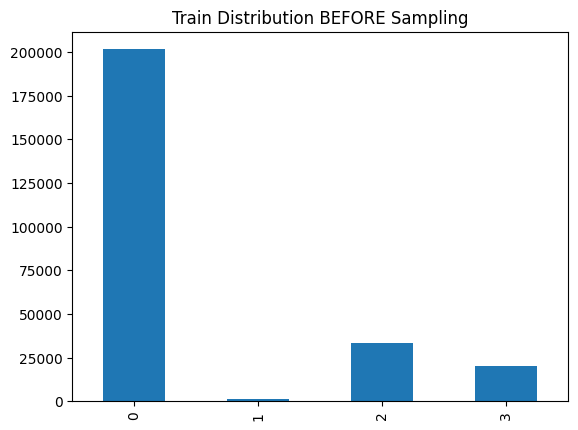

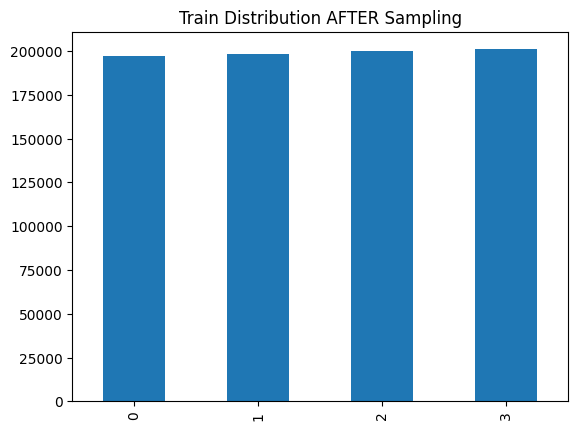

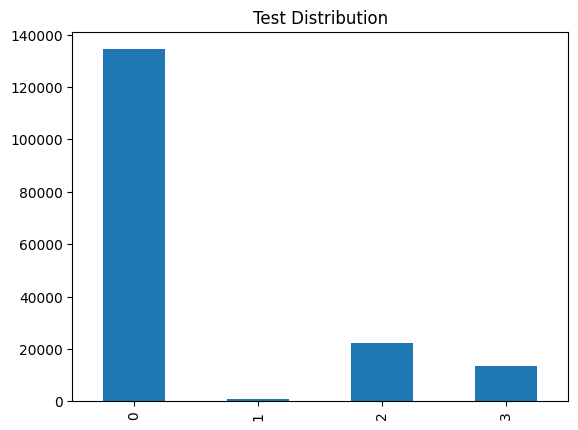

Train size: 796541 Test size: 171050
Epoch 1: Loss=0.0723, TrainAcc=0.9770, TestAcc=0.9736, ROC-AUC=0.9989
Epoch 2: Loss=0.0333, TrainAcc=0.9900, TestAcc=0.9786, ROC-AUC=0.9990
Epoch 3: Loss=0.0328, TrainAcc=0.9914, TestAcc=0.9790, ROC-AUC=0.9992
Epoch 4: Loss=0.0264, TrainAcc=0.9919, TestAcc=0.9810, ROC-AUC=0.9992
Epoch 5: Loss=0.0247, TrainAcc=0.9924, TestAcc=0.9802, ROC-AUC=0.9993
Epoch 6: Loss=0.0382, TrainAcc=0.9930, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 7: Loss=0.0246, TrainAcc=0.9931, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 8: Loss=0.0218, TrainAcc=0.9934, TestAcc=0.9808, ROC-AUC=0.9993
Epoch 9: Loss=0.0320, TrainAcc=0.9936, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 10: Loss=0.0235, TrainAcc=0.9938, TestAcc=0.9809, ROC-AUC=0.9993
Epoch 11: Loss=0.0200, TrainAcc=0.9939, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 12: Loss=0.0373, TrainAcc=0.9940, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 13: Loss=0.0194, TrainAcc=0.9941, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 14: Loss=0.0206, TrainAcc=0.9941, TestAcc=0

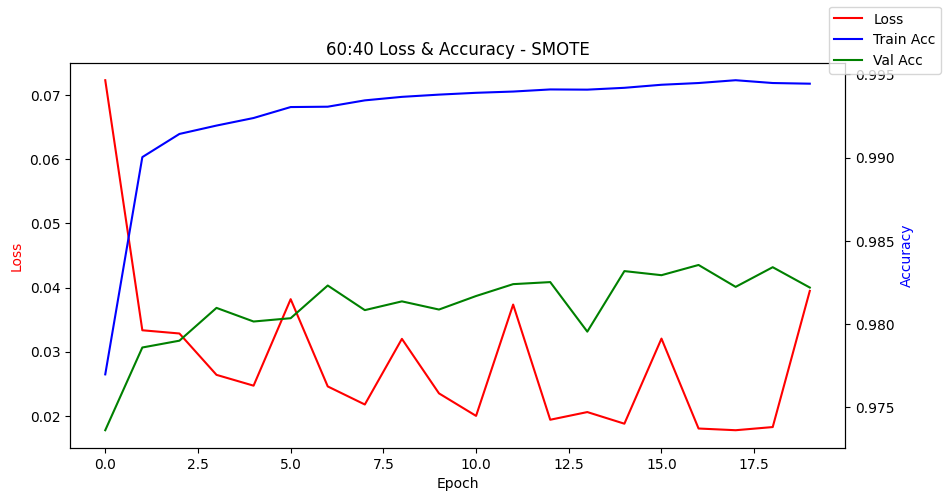

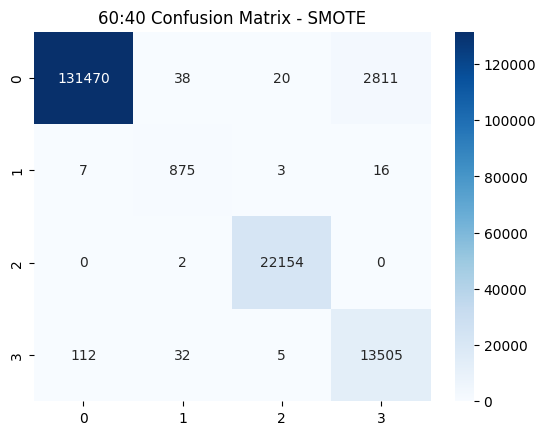

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.92      0.97      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.83      0.99      0.90     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.98      0.96    171050
weighted avg       0.98      0.98      0.98    171050



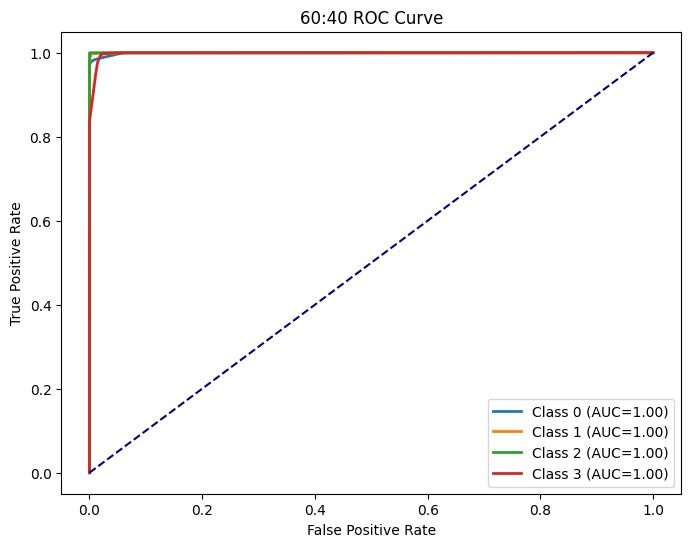

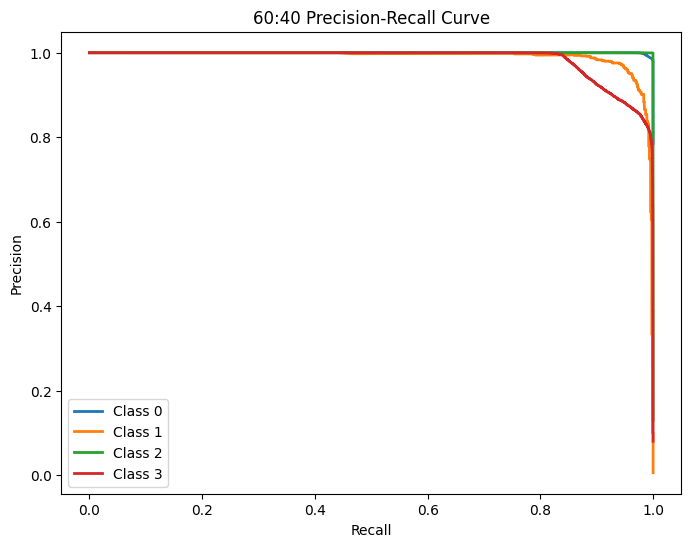


⏱️ Runtime: 2810.64 sec
💾 RAM used: 346.83 MB

========== 70:30 - ADASYN + TomekLinks ==========


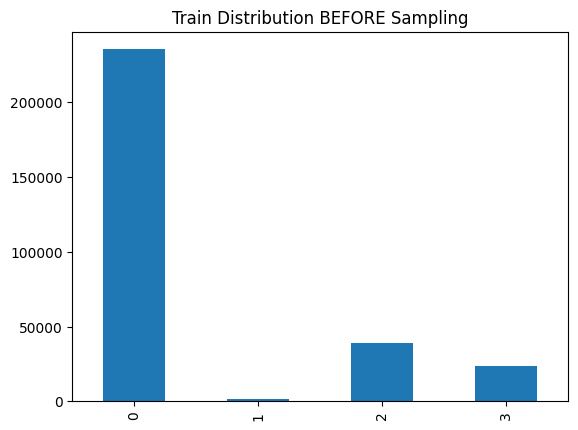

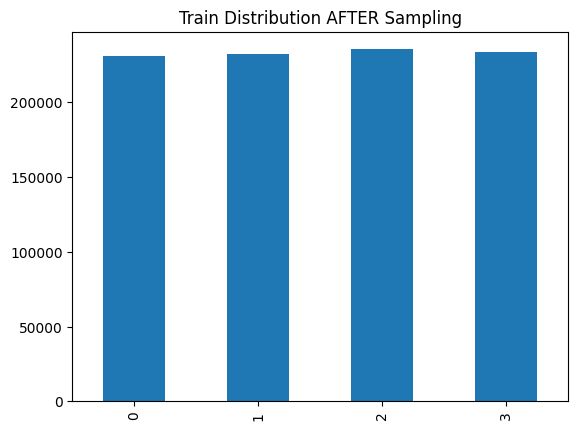

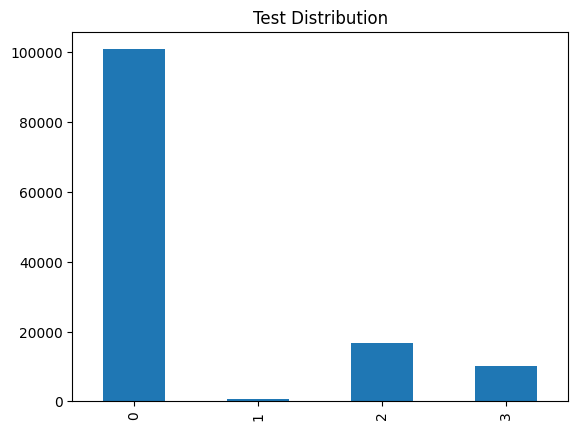

Train size: 931135 Test size: 128288
Epoch 1: Loss=0.0670, TrainAcc=0.9781, TestAcc=0.9761, ROC-AUC=0.9990
Epoch 2: Loss=0.0328, TrainAcc=0.9899, TestAcc=0.9791, ROC-AUC=0.9991
Epoch 3: Loss=0.0287, TrainAcc=0.9912, TestAcc=0.9794, ROC-AUC=0.9993
Epoch 4: Loss=0.0258, TrainAcc=0.9921, TestAcc=0.9799, ROC-AUC=0.9993
Epoch 5: Loss=0.0239, TrainAcc=0.9927, TestAcc=0.9813, ROC-AUC=0.9994
Epoch 6: Loss=0.0236, TrainAcc=0.9929, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 7: Loss=0.0226, TrainAcc=0.9931, TestAcc=0.9818, ROC-AUC=0.9993
Epoch 8: Loss=0.0216, TrainAcc=0.9934, TestAcc=0.9817, ROC-AUC=0.9993
Epoch 9: Loss=0.0210, TrainAcc=0.9937, TestAcc=0.9816, ROC-AUC=0.9993
Epoch 10: Loss=0.0217, TrainAcc=0.9937, TestAcc=0.9817, ROC-AUC=0.9994
Epoch 11: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9828, ROC-AUC=0.9994
Epoch 12: Loss=0.0203, TrainAcc=0.9939, TestAcc=0.9829, ROC-AUC=0.9994
Epoch 13: Loss=0.0198, TrainAcc=0.9941, TestAcc=0.9825, ROC-AUC=0.9994
Epoch 14: Loss=0.0194, TrainAcc=0.9941, TestAcc=0

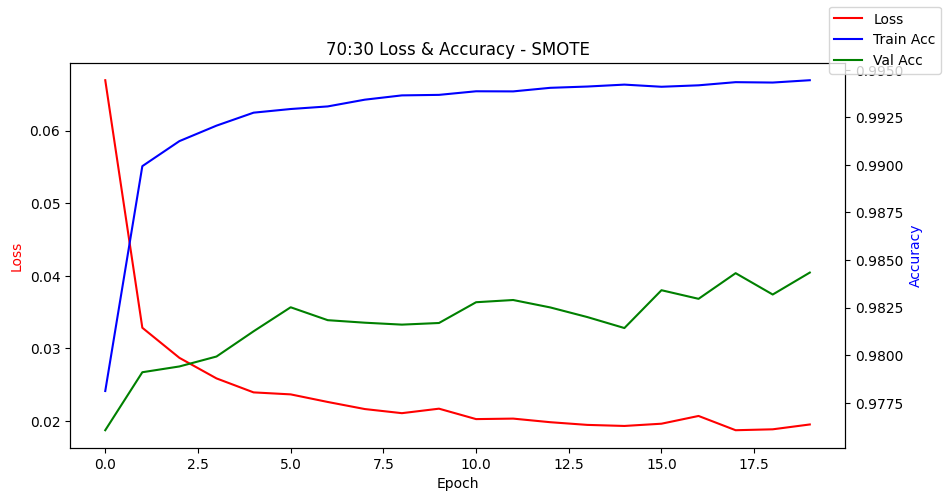

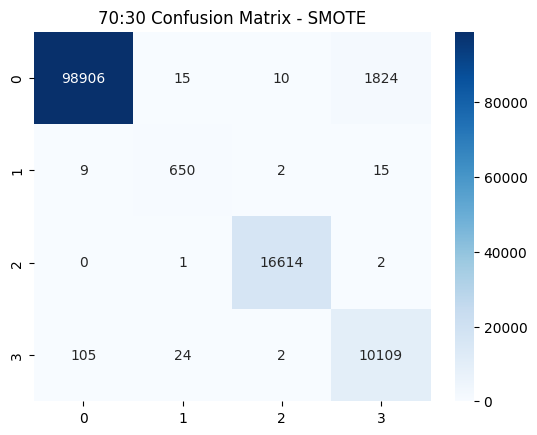

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.94      0.96      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.99      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.95      0.98      0.96    128288
weighted avg       0.99      0.98      0.98    128288



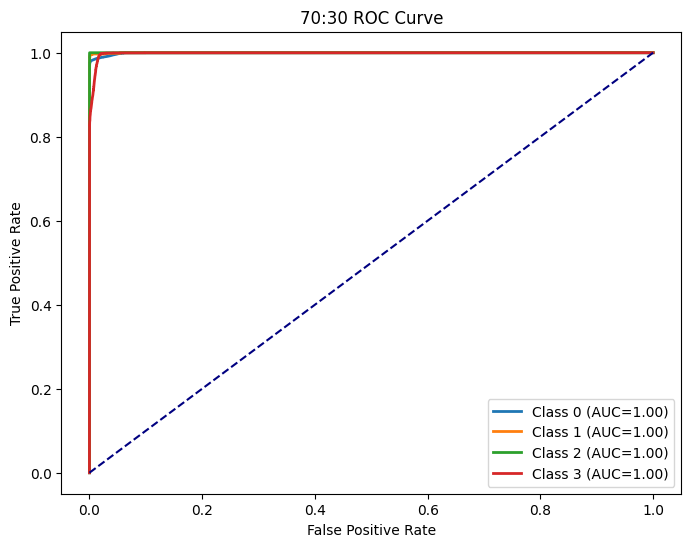

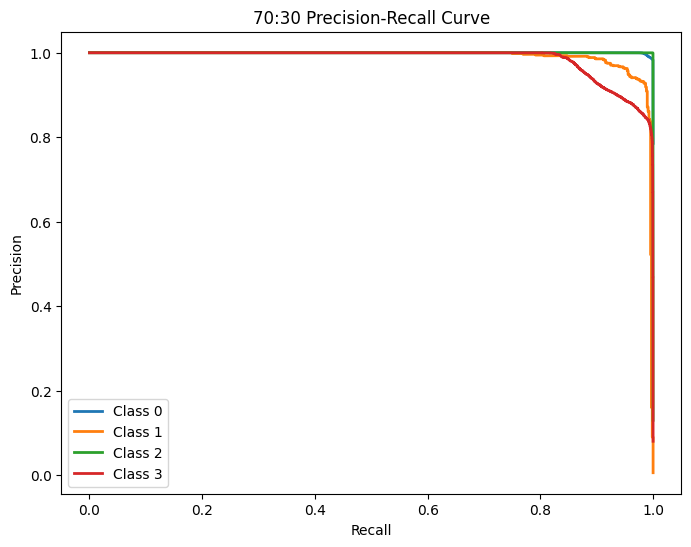


⏱️ Runtime: 3569.40 sec
💾 RAM used: 380.91 MB

========== 80:20 - ADASYN + TomekLinks ==========


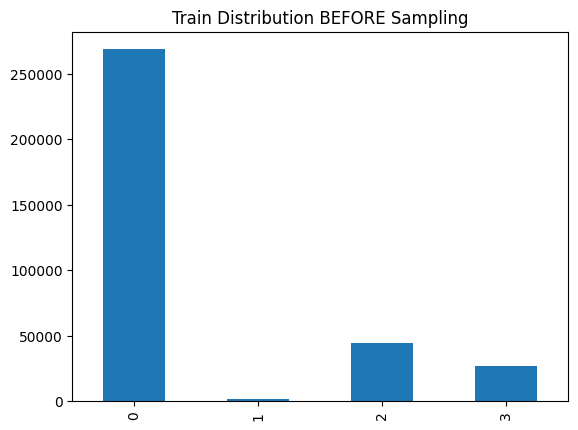

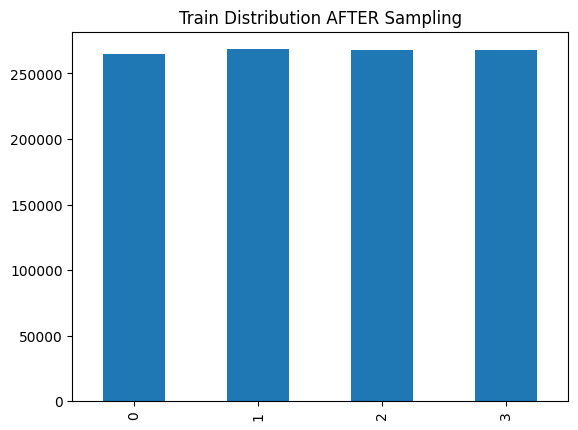

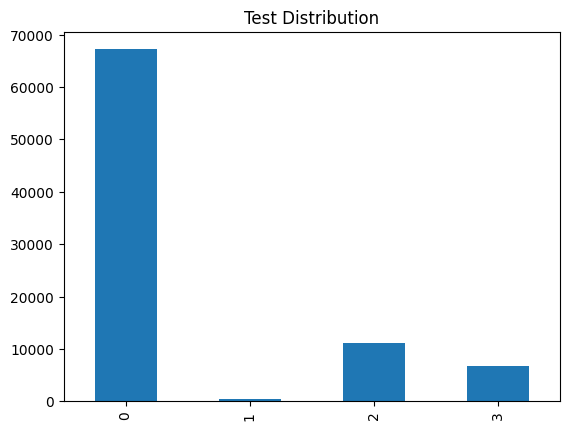

Train size: 1068144 Test size: 85525
Epoch 1: Loss=0.0661, TrainAcc=0.9787, TestAcc=0.9756, ROC-AUC=0.9991
Epoch 2: Loss=0.0333, TrainAcc=0.9898, TestAcc=0.9777, ROC-AUC=0.9992
Epoch 3: Loss=0.0288, TrainAcc=0.9913, TestAcc=0.9795, ROC-AUC=0.9992
Epoch 4: Loss=0.0266, TrainAcc=0.9920, TestAcc=0.9812, ROC-AUC=0.9993
Epoch 5: Loss=0.0254, TrainAcc=0.9923, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 6: Loss=0.0262, TrainAcc=0.9926, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 7: Loss=0.0234, TrainAcc=0.9929, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 8: Loss=0.0226, TrainAcc=0.9932, TestAcc=0.9809, ROC-AUC=0.9993
Epoch 9: Loss=0.0216, TrainAcc=0.9934, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 10: Loss=0.0212, TrainAcc=0.9936, TestAcc=0.9812, ROC-AUC=0.9993
Epoch 11: Loss=0.0207, TrainAcc=0.9937, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 12: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9833, ROC-AUC=0.9994
Epoch 13: Loss=0.0204, TrainAcc=0.9941, TestAcc=0.9818, ROC-AUC=0.9994
Epoch 14: Loss=0.0208, TrainAcc=0.9939, TestAcc=0

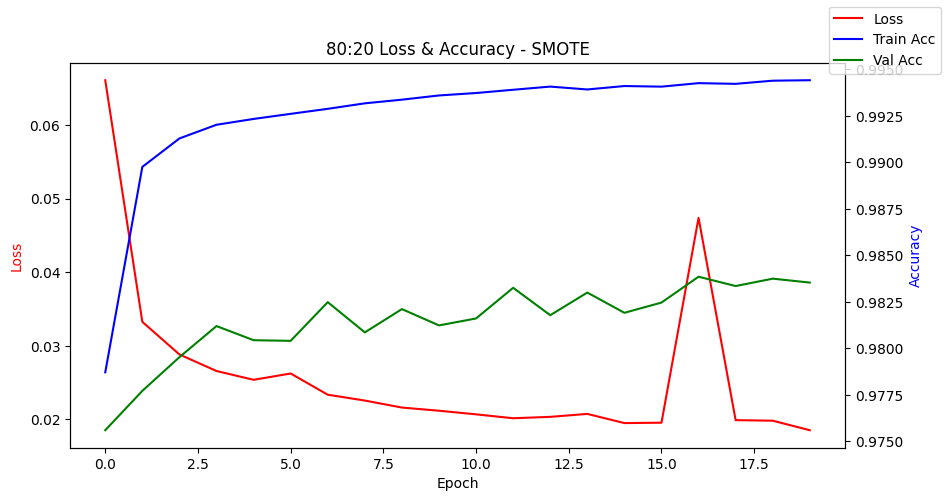

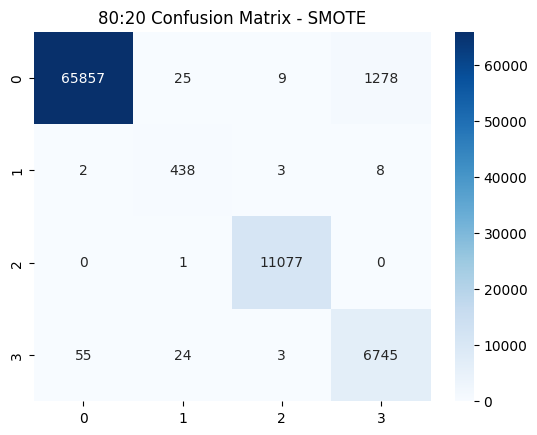

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.90      0.97      0.93       451
           2       1.00      1.00      1.00     11078
           3       0.84      0.99      0.91      6827

    accuracy                           0.98     85525
   macro avg       0.93      0.98      0.96     85525
weighted avg       0.99      0.98      0.98     85525



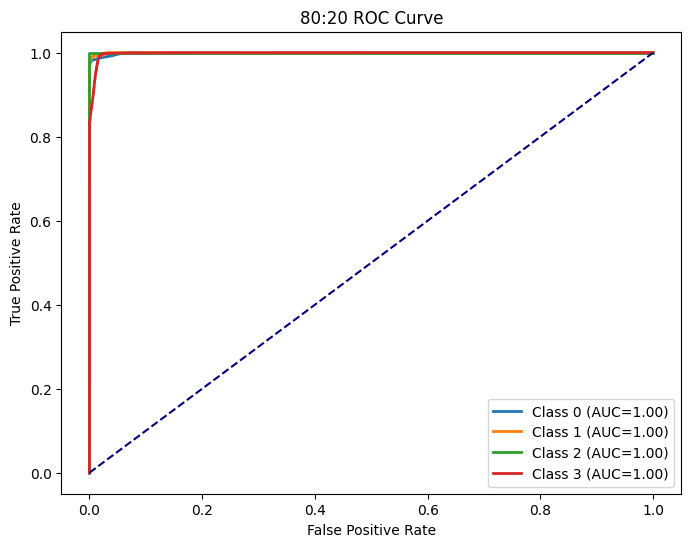

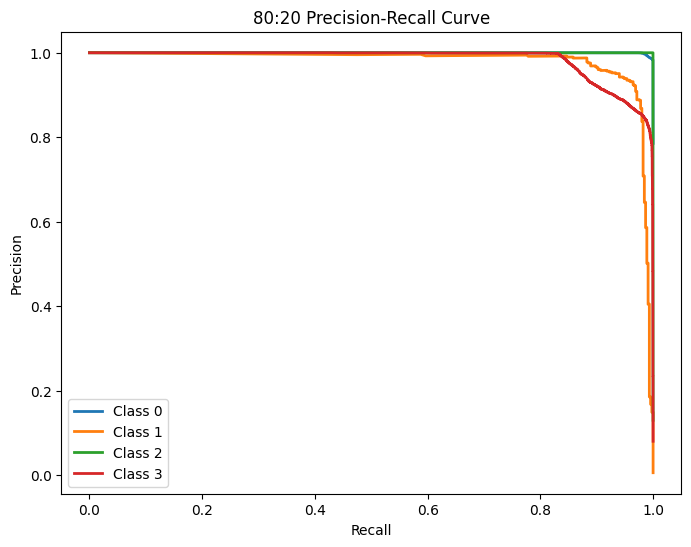


⏱️ Runtime: 4447.35 sec
💾 RAM used: 401.70 MB


In [12]:
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", test_size=0.4)
run_split_adasyn_tomek(df, "70:30", test_size=0.3)
run_split_adasyn_tomek(df, "80:20", test_size=0.2)